# GenAI Video Startups: Comprehensive Market Analysis

## Executive Investment Intelligence Report

**Prepared for:** Professional Committee Review  
**Analysis Date:** March 2026  
**Data Sources:** PitchBook, TechCrunch, Sacra, Company Filings

---

### Report Structure
1. Data Extraction & Methodology
2. Market Overview & Key Metrics
3. Funding Landscape Analysis
4. Valuation & Revenue Analysis
5. Geographic Distribution
6. Investor Network Analysis
7. Founder Profile Analysis
8. Competitive Positioning
9. Key Findings & Strategic Insights

In [1]:
# ============================================================
# SECTION 1: IMPORTS AND CONFIGURATION
# ============================================================

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

# Professional styling configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Custom color palette - Professional & Accessible
COLORS = {
    'primary': '#2C3E50',
    'secondary': '#3498DB',
    'accent': '#E74C3C',
    'success': '#27AE60',
    'warning': '#F39C12',
    'neutral': '#95A5A6',
    'dark': '#1A252F',
    'light': '#ECF0F1'
}

# Professional palette for charts
CHART_PALETTE = ['#2C3E50', '#3498DB', '#E74C3C', '#27AE60', '#F39C12', 
                 '#9B59B6', '#1ABC9C', '#E67E22', '#34495E', '#16A085',
                 '#C0392B', '#8E44AD', '#2980B9', '#D35400', '#7F8C8D']

# Figure defaults
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.labelweight'] = 'medium'

print("Configuration loaded successfully.")

Configuration loaded successfully.


In [2]:
# ============================================================
# SECTION 2: DATA EXTRACTION
# ============================================================

# Load JSON data files
with open('ai_video_companies_research.json', 'r', encoding='utf-8') as f:
    ai_video_data = json.load(f)

with open('genai_video_companies_research.json', 'r', encoding='utf-8') as f:
    genai_data = json.load(f)

# Extract companies from both sources
companies_list = ai_video_data.get('ai_video_companies', [])
genai_companies = genai_data.get('companies', [])

# Merge unique companies (avoid duplicates like Synthesia)
existing_names = {c['company_name'] for c in companies_list}
for company in genai_companies:
    if company['company_name'] not in existing_names:
        companies_list.append(company)

print(f"Total companies loaded: {len(companies_list)}")

Total companies loaded: 14


In [3]:
# ============================================================
# SECTION 3: DATA STRUCTURING & TRANSFORMATION
# ============================================================

def extract_country(headquarters):
    """Extract country from headquarters string."""
    if not headquarters:
        return 'Unknown'
    hq = headquarters.lower()
    if 'china' in hq or 'shanghai' in hq or 'beijing' in hq or 'shenzhen' in hq:
        return 'China'
    elif 'uk' in hq or 'london' in hq or 'united kingdom' in hq:
        return 'United Kingdom'
    elif 'israel' in hq or 'tel aviv' in hq:
        return 'Israel'
    elif 'canada' in hq or 'toronto' in hq:
        return 'Canada'
    elif any(state in hq for state in ['ca', 'ny', 'california', 'new york', 'texas', 'seattle', 'palo alto', 'mountain view', 'los angeles', 'austin']):
        return 'United States'
    elif 'usa' in hq or 'united states' in hq:
        return 'United States'
    return 'United States'  # Default assumption for ambiguous cases

def extract_region(country):
    """Map country to broader region."""
    region_map = {
        'United States': 'North America',
        'Canada': 'North America',
        'United Kingdom': 'Europe',
        'Israel': 'Middle East',
        'China': 'Asia Pacific'
    }
    return region_map.get(country, 'Other')

def categorize_stage(total_funding):
    """Categorize company by funding stage."""
    if total_funding is None:
        return 'Unknown'
    elif total_funding < 50_000_000:
        return 'Early Stage (<$50M)'
    elif total_funding < 150_000_000:
        return 'Growth Stage ($50M-$150M)'
    elif total_funding < 500_000_000:
        return 'Late Stage ($150M-$500M)'
    else:
        return 'Mega Round ($500M+)'

def calculate_funding_efficiency(valuation, total_funding):
    """Calculate funding efficiency ratio (valuation / funding)."""
    if valuation and total_funding and total_funding > 0:
        return round(valuation / total_funding, 2)
    return None

def calculate_company_age(founded_year):
    """Calculate company age in years."""
    if founded_year:
        return 2026 - founded_year
    return None

# Build structured DataFrame
companies_data = []

for company in companies_list:
    # Handle different JSON structures
    total_funding = company.get('total_funding_usd') or company.get('total_funding_usd')
    valuation = company.get('valuation_usd')
    revenue = company.get('revenue_arr_usd') or company.get('revenue_arr')
    
    country = extract_country(company.get('headquarters', ''))
    
    companies_data.append({
        'company_name': company.get('company_name'),
        'founded_year': company.get('founded_year'),
        'company_age': calculate_company_age(company.get('founded_year')),
        'headquarters': company.get('headquarters'),
        'country': country,
        'region': extract_region(country),
        'total_funding_usd': total_funding,
        'total_funding_millions': total_funding / 1_000_000 if total_funding else None,
        'valuation_usd': valuation,
        'valuation_billions': valuation / 1_000_000_000 if valuation else None,
        'revenue_arr_usd': revenue,
        'revenue_arr_millions': revenue / 1_000_000 if revenue else None,
        'revenue_multiple': company.get('revenue_multiple'),
        'funding_stage': categorize_stage(total_funding),
        'funding_efficiency': calculate_funding_efficiency(valuation, total_funding),
        'num_founders': len(company.get('founders', [])),
        'num_products': len(company.get('key_products', [])),
        'num_investors': len(company.get('investors', [])),
        'is_unicorn': valuation >= 1_000_000_000 if valuation else False,
        'tagline': company.get('slogan_tagline'),
        'target_market': company.get('target_market')
    })

# Create main DataFrame
df_companies = pd.DataFrame(companies_data)

# Sort by total funding descending
df_companies = df_companies.sort_values('total_funding_usd', ascending=False).reset_index(drop=True)

print(f"DataFrame created with {len(df_companies)} companies and {len(df_companies.columns)} features")
df_companies.head()

DataFrame created with 14 companies and 21 features


,company_name,founded_year,company_age,headquarters,country,region,total_funding_usd,total_funding_millions,valuation_usd,valuation_billions,...,revenue_arr_millions,revenue_multiple,funding_stage,funding_efficiency,num_founders,num_products,num_investors,is_unicorn,tagline,target_market
0,MiniMax,2021,5,"Shanghai, China",China,Asia Pacific,1150000000,1150.0,1.280000e+10,12.8,...,NaN,NaN,Mega Round ($500M+),11.13,4,8,7,True,Intelligence with Everyone,"Global consumers (B2C-first approach), enterpr..."
1,Luma AI,2021,5,"Palo Alto, California",United States,North America,1000000000,1000.0,4.000000e+09,4.0,...,8.0,500.0,Mega Round ($500M+),4.00,3,7,10,True,Dream Machine - generate realistic videos from...,"Creative industries including filmmaking, gami..."
2,Runway,2018,8,"New York, NY",United States,North America,544500000,544.5,3.000000e+09,3.0,...,NaN,NaN,Mega Round ($500M+),5.51,3,7,8,True,Advancing creativity with AI,"Professional filmmakers, video creators, desig..."
3,Synthesia,2017,9,"London, UK",United Kingdom,Europe,536000000,536.0,2.100000e+09,2.1,...,100.0,21.0,Mega Round ($500M+),3.92,2,7,8,True,Making video as easy as writing a doc,"Enterprises for training, marketing, sales ena..."
4,Hugging Face,2016,10,"Brooklyn, New York, United States",United States,North America,395000000,395.0,4.500000e+09,4.5,...,NaN,NaN,Late Stage ($150M-$500M),11.39,3,7,0,True,"AI community, building the future",NaN


In [4]:
# ============================================================
# SECTION 4: FOUNDERS DATA EXTRACTION
# ============================================================

founders_data = []

for company in companies_list:
    company_name = company.get('company_name')
    founders = company.get('founders', [])
    
    for founder in founders:
        bio = founder.get('bio') or founder.get('biography', '')
        
        # Extract education indicators
        has_phd = 'phd' in bio.lower() if bio else False
        has_masters = any(term in bio.lower() for term in ['master', 'msc', 'mba', 'mphil']) if bio else False
        
        # Extract background indicators
        is_ex_google = 'google' in bio.lower() if bio else False
        is_ex_meta = any(term in bio.lower() for term in ['meta', 'facebook']) if bio else False
        is_ex_apple = 'apple' in bio.lower() if bio else False
        is_academic = any(term in bio.lower() for term in ['professor', 'researcher', 'phd', 'university']) if bio else False
        is_serial_founder = any(term in bio.lower() for term in ['co-founded', 'founded', 'co-founder']) if bio else False
        
        # Elite university indicators
        elite_unis = ['stanford', 'mit', 'harvard', 'berkeley', 'oxford', 'cambridge', 'nyu', 'carnegie mellon']
        has_elite_education = any(uni in bio.lower() for uni in elite_unis) if bio else False
        
        founders_data.append({
            'company_name': company_name,
            'founder_name': founder.get('name'),
            'role': founder.get('role'),
            'has_phd': has_phd,
            'has_masters': has_masters,
            'has_elite_education': has_elite_education,
            'is_ex_google': is_ex_google,
            'is_ex_meta': is_ex_meta,
            'is_ex_apple': is_ex_apple,
            'is_academic_background': is_academic,
            'is_serial_founder': is_serial_founder,
            'bio': bio
        })

df_founders = pd.DataFrame(founders_data)
print(f"Founders DataFrame: {len(df_founders)} founders across {df_founders['company_name'].nunique()} companies")
df_founders.head()

Founders DataFrame: 40 founders across 14 companies


,company_name,founder_name,role,has_phd,has_masters,has_elite_education,is_ex_google,is_ex_meta,is_ex_apple,is_academic_background,is_serial_founder,bio
0,Runway,Cristóbal Valenzuela,Co-founder & CEO,False,False,True,False,False,False,True,False,"Chilean artist, researcher, and entrepreneur. ..."
1,Runway,Anastasis Germanidis,Co-founder & CTO,False,False,True,False,False,False,True,False,"Greek AI researcher, software engineer, and ar..."
2,Runway,Alejandro Matamala,Co-founder & Chief Design Officer,False,False,True,False,False,False,False,False,Chilean designer and creative technologist. Gr...
3,Synthesia,Victor Riparbelli,CEO & Co-founder,False,False,True,False,False,False,True,True,Danish entrepreneur. BSc in Computer Science a...
4,Synthesia,Steffen Tjerrild,CFO & COO & Co-founder,False,True,False,False,False,False,False,True,Danish executive. Master's in Applied Economic...


In [5]:
# ============================================================
# SECTION 5: INVESTORS DATA EXTRACTION
# ============================================================

investors_data = []

for company in companies_list:
    company_name = company.get('company_name')
    investors = company.get('investors', [])
    
    for investor in investors:
        # Categorize investor type
        investor_lower = investor.lower()
        if any(term in investor_lower for term in ['google', 'nvidia', 'amazon', 'microsoft', 'salesforce', 'adobe', 'intel']):
            investor_type = 'Strategic/Corporate'
        elif any(term in investor_lower for term in ['a16z', 'andreessen', 'sequoia', 'accel', 'lightspeed', 'benchmark', 'kleiner', 'nea', 'greylock']):
            investor_type = 'Tier 1 VC'
        elif 'capital' in investor_lower or 'ventures' in investor_lower or 'partners' in investor_lower:
            investor_type = 'VC Fund'
        elif any(term in investor_lower for term in ['sovereign', 'humain']):
            investor_type = 'Sovereign Wealth'
        else:
            investor_type = 'Other/Angel'
        
        investors_data.append({
            'company_name': company_name,
            'investor_name': investor,
            'investor_type': investor_type
        })

df_investors = pd.DataFrame(investors_data)
print(f"Investors DataFrame: {len(df_investors)} investment relationships")
print(f"Unique investors: {df_investors['investor_name'].nunique()}")
df_investors.head(10)

Investors DataFrame: 83 investment relationships
Unique investors: 75


,company_name,investor_name,investor_type
0,Runway,Google,Strategic/Corporate
1,Runway,Salesforce Ventures,Strategic/Corporate
2,Runway,NVIDIA,Strategic/Corporate
3,Runway,Lux Capital,VC Fund
4,Runway,Amplify Partners,VC Fund
5,Runway,Compound,Other/Angel
6,Runway,Ann Miura-Ko,Other/Angel
7,Runway,Eric Schmidt,Other/Angel
8,Synthesia,NEA,Tier 1 VC
9,Synthesia,GV (Google Ventures),Strategic/Corporate


---

## 2. Market Overview & Key Metrics

This section provides aggregate statistics and high-level market insights.

In [6]:
# ============================================================
# SECTION 6: KEY MARKET METRICS
# ============================================================

# Calculate key metrics
total_funding_all = df_companies['total_funding_usd'].sum()
total_valuation_all = df_companies['valuation_usd'].sum()
total_revenue_all = df_companies['revenue_arr_usd'].sum()

num_unicorns = df_companies['is_unicorn'].sum()
avg_funding = df_companies['total_funding_usd'].mean()
median_funding = df_companies['total_funding_usd'].median()

avg_valuation = df_companies[df_companies['valuation_usd'].notna()]['valuation_usd'].mean()
avg_company_age = df_companies['company_age'].mean()

# Create summary metrics display
metrics_summary = pd.DataFrame({
    'Metric': [
        'Total Companies Analyzed',
        'Total Funding Raised',
        'Total Market Valuation',
        'Total ARR (Reported)',
        'Number of Unicorns',
        'Average Funding per Company',
        'Median Funding per Company',
        'Average Valuation',
        'Average Company Age'
    ],
    'Value': [
        f"{len(df_companies)}",
        f"${total_funding_all/1e9:.2f}B",
        f"${total_valuation_all/1e9:.2f}B",
        f"${total_revenue_all/1e6:.0f}M",
        f"{num_unicorns} companies",
        f"${avg_funding/1e6:.0f}M",
        f"${median_funding/1e6:.0f}M",
        f"${avg_valuation/1e9:.2f}B",
        f"{avg_company_age:.1f} years"
    ]
})

print("="*60)
print("       GENAI VIDEO MARKET: KEY METRICS SUMMARY")
print("="*60)
for _, row in metrics_summary.iterrows():
    print(f"{row['Metric']:<35} {row['Value']:>20}")
print("="*60)

       GENAI VIDEO MARKET: KEY METRICS SUMMARY
Total Companies Analyzed                              14
Total Funding Raised                              $4.88B
Total Market Valuation                           $37.77B
Total ARR (Reported)                               $809M
Number of Unicorns                           9 companies
Average Funding per Company                        $348M
Median Funding per Company                         $160M
Average Valuation                                 $3.43B
Average Company Age                            5.4 years


In [7]:
# ============================================================
# SECTION 7: STATISTICAL SUMMARY
# ============================================================

# Detailed statistical summary
numerical_cols = ['total_funding_millions', 'valuation_billions', 'revenue_arr_millions', 
                  'revenue_multiple', 'funding_efficiency', 'company_age', 'num_founders', 'num_products']

stats_summary = df_companies[numerical_cols].describe().T
stats_summary['missing'] = df_companies[numerical_cols].isna().sum()
stats_summary['missing_pct'] = (stats_summary['missing'] / len(df_companies) * 100).round(1)

print("\nDetailed Statistical Summary:")
print("-" * 80)
stats_summary[['count', 'mean', 'std', 'min', '50%', 'max', 'missing_pct']].round(2)


Detailed Statistical Summary:
--------------------------------------------------------------------------------


,count,mean,std,min,50%,max,missing_pct
total_funding_millions,14.0,348.25,347.51,65.00,159.50,1150.00,0.0
valuation_billions,11.0,3.43,3.64,0.47,2.10,12.80,21.4
revenue_arr_millions,8.0,101.08,113.63,7.60,77.50,330.00,42.9
revenue_multiple,6.0,102.38,195.87,5.00,20.50,500.00,57.1
funding_efficiency,11.0,8.78,5.77,3.48,6.76,23.49,21.4
company_age,14.0,5.43,2.21,3.00,5.00,10.00,0.0
num_founders,14.0,2.86,1.17,1.00,3.00,5.00,0.0
num_products,14.0,7.21,1.37,6.00,7.00,11.00,0.0


---

## 3. Funding Landscape Analysis

Comprehensive analysis of funding distribution, stages, and capital allocation across the GenAI video ecosystem.

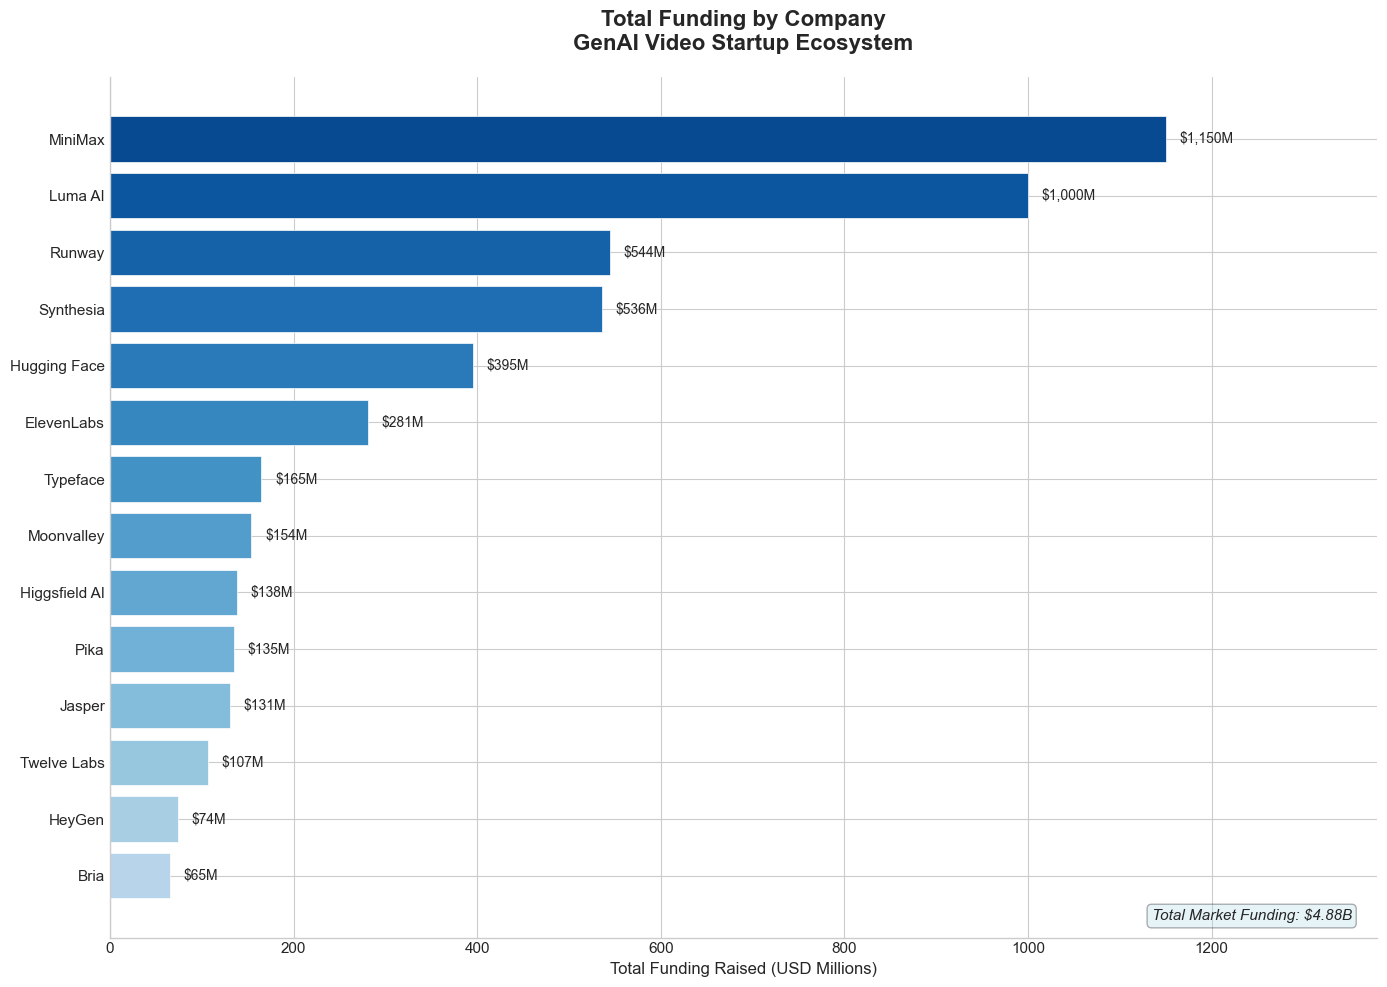

Saved: viz_01_funding_by_company.png


In [8]:
# ============================================================
# VISUALIZATION 1: TOTAL FUNDING BY COMPANY (HORIZONTAL BAR)
# ============================================================

fig, ax = plt.subplots(figsize=(14, 10))

# Prepare data
funding_data = df_companies[['company_name', 'total_funding_millions']].dropna()
funding_data = funding_data.sort_values('total_funding_millions', ascending=True)

# Create color gradient based on funding
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(funding_data)))

# Plot horizontal bars
bars = ax.barh(funding_data['company_name'], funding_data['total_funding_millions'], 
               color=colors, edgecolor='white', linewidth=0.5)

# Add value labels
for bar, value in zip(bars, funding_data['total_funding_millions']):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2, 
            f'${value:,.0f}M', va='center', fontsize=10, fontweight='medium')

# Styling
ax.set_xlabel('Total Funding Raised (USD Millions)', fontsize=12, fontweight='medium')
ax.set_title('Total Funding by Company\nGenAI Video Startup Ecosystem', fontsize=16, fontweight='bold', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, max(funding_data['total_funding_millions']) * 1.2)

# Add market context annotation
ax.annotate(f'Total Market Funding: ${total_funding_all/1e9:.2f}B', 
            xy=(0.98, 0.02), xycoords='axes fraction',
            fontsize=11, ha='right', style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.3))

plt.tight_layout()
plt.savefig('viz_01_funding_by_company.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: viz_01_funding_by_company.png")

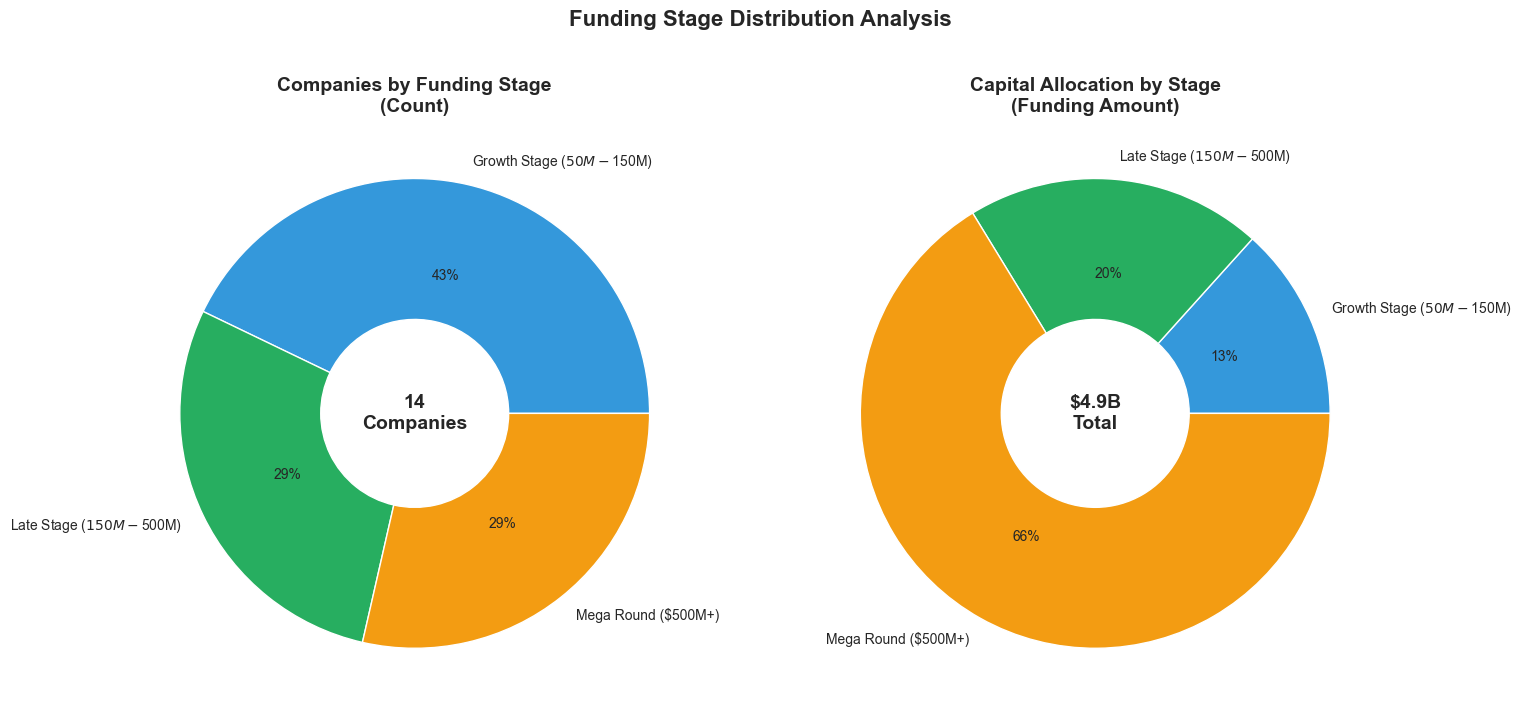

Saved: viz_02_funding_stage_distribution.png


In [9]:
# ============================================================
# VISUALIZATION 2: FUNDING STAGE DISTRIBUTION (DONUT CHART)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Count by stage
stage_counts = df_companies['funding_stage'].value_counts()
stage_order = ['Early Stage (<$50M)', 'Growth Stage ($50M-$150M)', 'Late Stage ($150M-$500M)', 'Mega Round ($500M+)']
stage_counts = stage_counts.reindex([s for s in stage_order if s in stage_counts.index])

colors_stage = ['#3498DB', '#27AE60', '#F39C12', '#E74C3C']
wedges, texts, autotexts = axes[0].pie(stage_counts.values, labels=stage_counts.index, 
                                        autopct='%1.0f%%', colors=colors_stage[:len(stage_counts)],
                                        wedgeprops=dict(width=0.6, edgecolor='white'),
                                        textprops={'fontsize': 10})
axes[0].set_title('Companies by Funding Stage\n(Count)', fontsize=14, fontweight='bold')

# Center text
axes[0].text(0, 0, f'{len(df_companies)}\nCompanies', ha='center', va='center', fontsize=14, fontweight='bold')

# Right: Funding amount by stage
stage_funding = df_companies.groupby('funding_stage')['total_funding_millions'].sum()
stage_funding = stage_funding.reindex([s for s in stage_order if s in stage_funding.index])

wedges2, texts2, autotexts2 = axes[1].pie(stage_funding.values, labels=stage_funding.index,
                                           autopct='%1.0f%%', colors=colors_stage[:len(stage_funding)],
                                           wedgeprops=dict(width=0.6, edgecolor='white'),
                                           textprops={'fontsize': 10})
axes[1].set_title('Capital Allocation by Stage\n(Funding Amount)', fontsize=14, fontweight='bold')

# Center text
axes[1].text(0, 0, f'${total_funding_all/1e9:.1f}B\nTotal', ha='center', va='center', fontsize=14, fontweight='bold')

plt.suptitle('Funding Stage Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_02_funding_stage_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: viz_02_funding_stage_distribution.png")

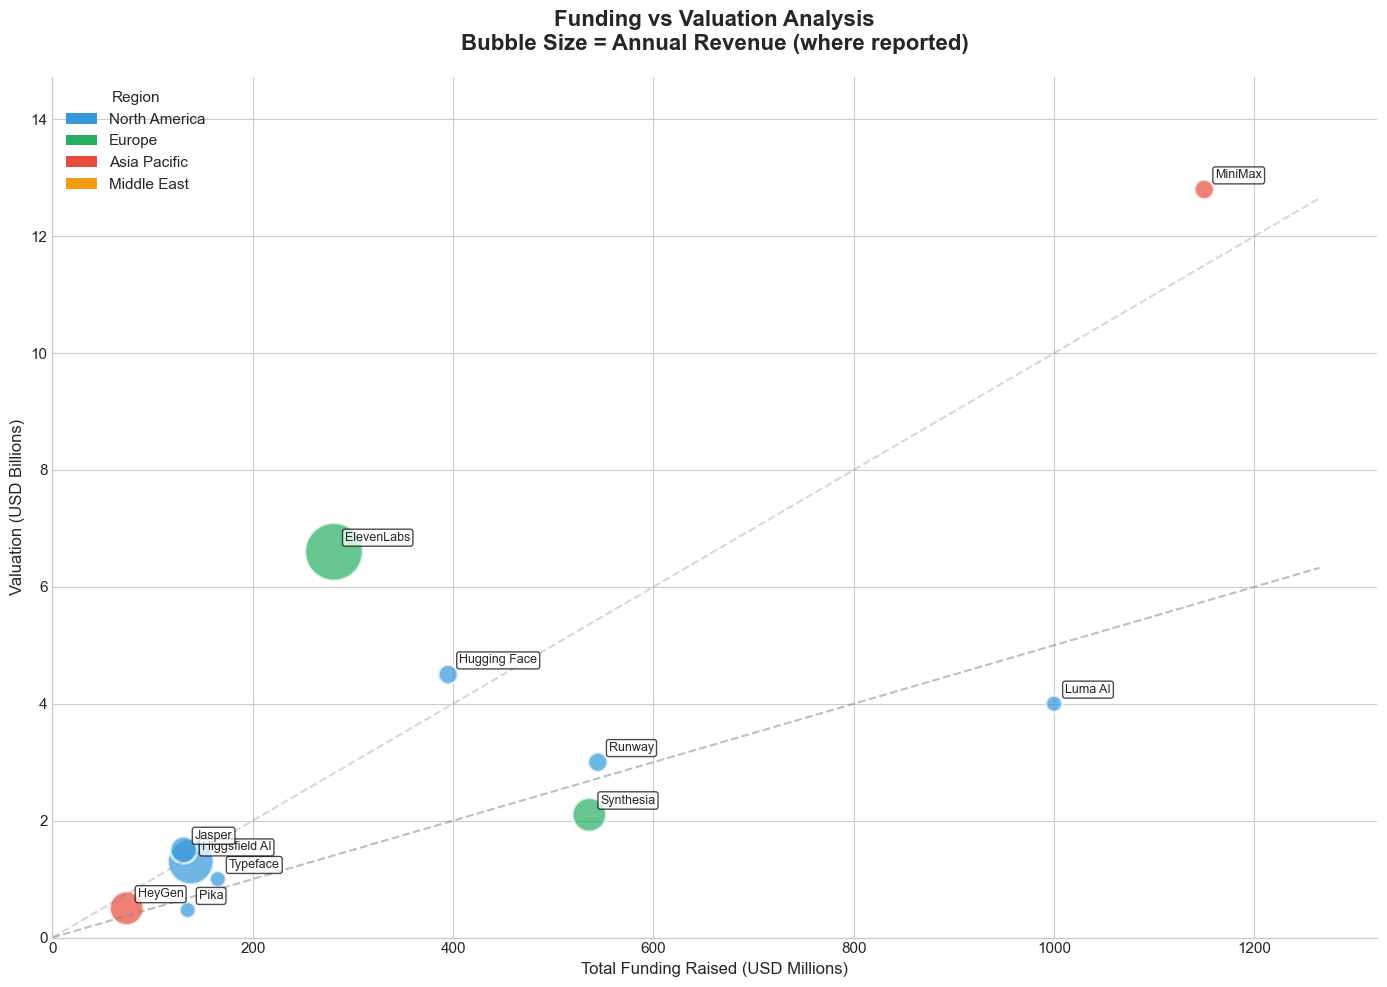

Saved: viz_03_funding_vs_valuation.png


In [10]:
# ============================================================
# VISUALIZATION 3: FUNDING vs VALUATION BUBBLE CHART
# ============================================================

fig, ax = plt.subplots(figsize=(14, 10))

# Filter to companies with both funding and valuation
bubble_data = df_companies[df_companies['valuation_usd'].notna()].copy()

# Bubble size based on revenue (if available), else fixed size
bubble_data['bubble_size'] = bubble_data['revenue_arr_millions'].fillna(20) * 5 + 100

# Color by region
region_colors = {'North America': '#3498DB', 'Europe': '#27AE60', 'Asia Pacific': '#E74C3C', 'Middle East': '#F39C12'}
bubble_data['color'] = bubble_data['region'].map(region_colors)

# Create scatter plot
scatter = ax.scatter(bubble_data['total_funding_millions'], 
                     bubble_data['valuation_billions'],
                     s=bubble_data['bubble_size'],
                     c=bubble_data['color'],
                     alpha=0.7,
                     edgecolors='white',
                     linewidth=2)

# Add company labels
for idx, row in bubble_data.iterrows():
    ax.annotate(row['company_name'], 
                (row['total_funding_millions'], row['valuation_billions']),
                xytext=(8, 8), textcoords='offset points',
                fontsize=9, fontweight='medium',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Add reference lines
funding_range = np.linspace(0, bubble_data['total_funding_millions'].max() * 1.1, 100)
ax.plot(funding_range, funding_range/1000 * 5, '--', color='gray', alpha=0.5, label='5x Funding Efficiency')
ax.plot(funding_range, funding_range/1000 * 10, '--', color='gray', alpha=0.3, label='10x Funding Efficiency')

# Legend for regions
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=region) for region, color in region_colors.items()]
ax.legend(handles=legend_elements, loc='upper left', title='Region', framealpha=0.9)

# Styling
ax.set_xlabel('Total Funding Raised (USD Millions)', fontsize=12, fontweight='medium')
ax.set_ylabel('Valuation (USD Billions)', fontsize=12, fontweight='medium')
ax.set_title('Funding vs Valuation Analysis\nBubble Size = Annual Revenue (where reported)', 
             fontsize=16, fontweight='bold', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, bubble_data['total_funding_millions'].max() * 1.15)
ax.set_ylim(0, bubble_data['valuation_billions'].max() * 1.15)

plt.tight_layout()
plt.savefig('viz_03_funding_vs_valuation.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: viz_03_funding_vs_valuation.png")

---

## 4. Valuation & Revenue Multiple Analysis

Deep dive into valuation efficiency and revenue multiples across the market.

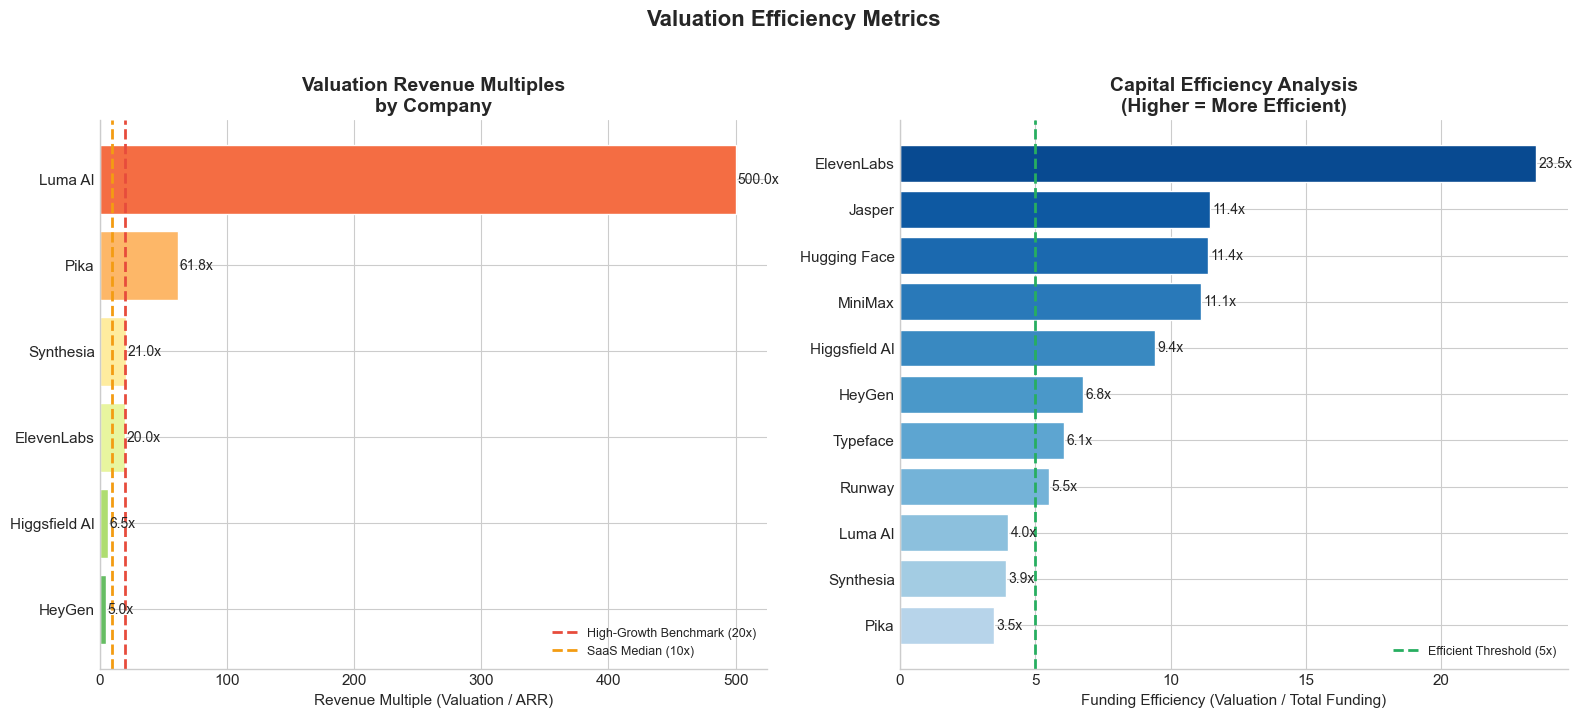

Saved: viz_04_revenue_multiples.png


In [11]:
# ============================================================
# VISUALIZATION 4: REVENUE MULTIPLES COMPARISON
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Companies with reported revenue multiples
revenue_data = df_companies[df_companies['revenue_multiple'].notna()].copy()
revenue_data = revenue_data.sort_values('revenue_multiple', ascending=True)

colors_mult = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(revenue_data)))

bars = axes[0].barh(revenue_data['company_name'], revenue_data['revenue_multiple'], 
                    color=colors_mult, edgecolor='white')

# Add value labels
for bar, value in zip(bars, revenue_data['revenue_multiple']):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{value:.1f}x', va='center', fontsize=10, fontweight='medium')

# Add benchmark line (median SaaS multiple ~10x)
axes[0].axvline(x=20, color='#E74C3C', linestyle='--', linewidth=2, label='High-Growth Benchmark (20x)')
axes[0].axvline(x=10, color='#F39C12', linestyle='--', linewidth=2, label='SaaS Median (10x)')

axes[0].set_xlabel('Revenue Multiple (Valuation / ARR)', fontsize=11)
axes[0].set_title('Valuation Revenue Multiples\nby Company', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: Funding efficiency (valuation / total funding)
efficiency_data = df_companies[df_companies['funding_efficiency'].notna()].copy()
efficiency_data = efficiency_data.sort_values('funding_efficiency', ascending=True)

colors_eff = plt.cm.Blues(np.linspace(0.3, 0.9, len(efficiency_data)))

bars2 = axes[1].barh(efficiency_data['company_name'], efficiency_data['funding_efficiency'],
                     color=colors_eff, edgecolor='white')

# Add value labels
for bar, value in zip(bars2, efficiency_data['funding_efficiency']):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{value:.1f}x', va='center', fontsize=10, fontweight='medium')

axes[1].axvline(x=5, color='#27AE60', linestyle='--', linewidth=2, label='Efficient Threshold (5x)')

axes[1].set_xlabel('Funding Efficiency (Valuation / Total Funding)', fontsize=11)
axes[1].set_title('Capital Efficiency Analysis\n(Higher = More Efficient)', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Valuation Efficiency Metrics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_04_revenue_multiples.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: viz_04_revenue_multiples.png")

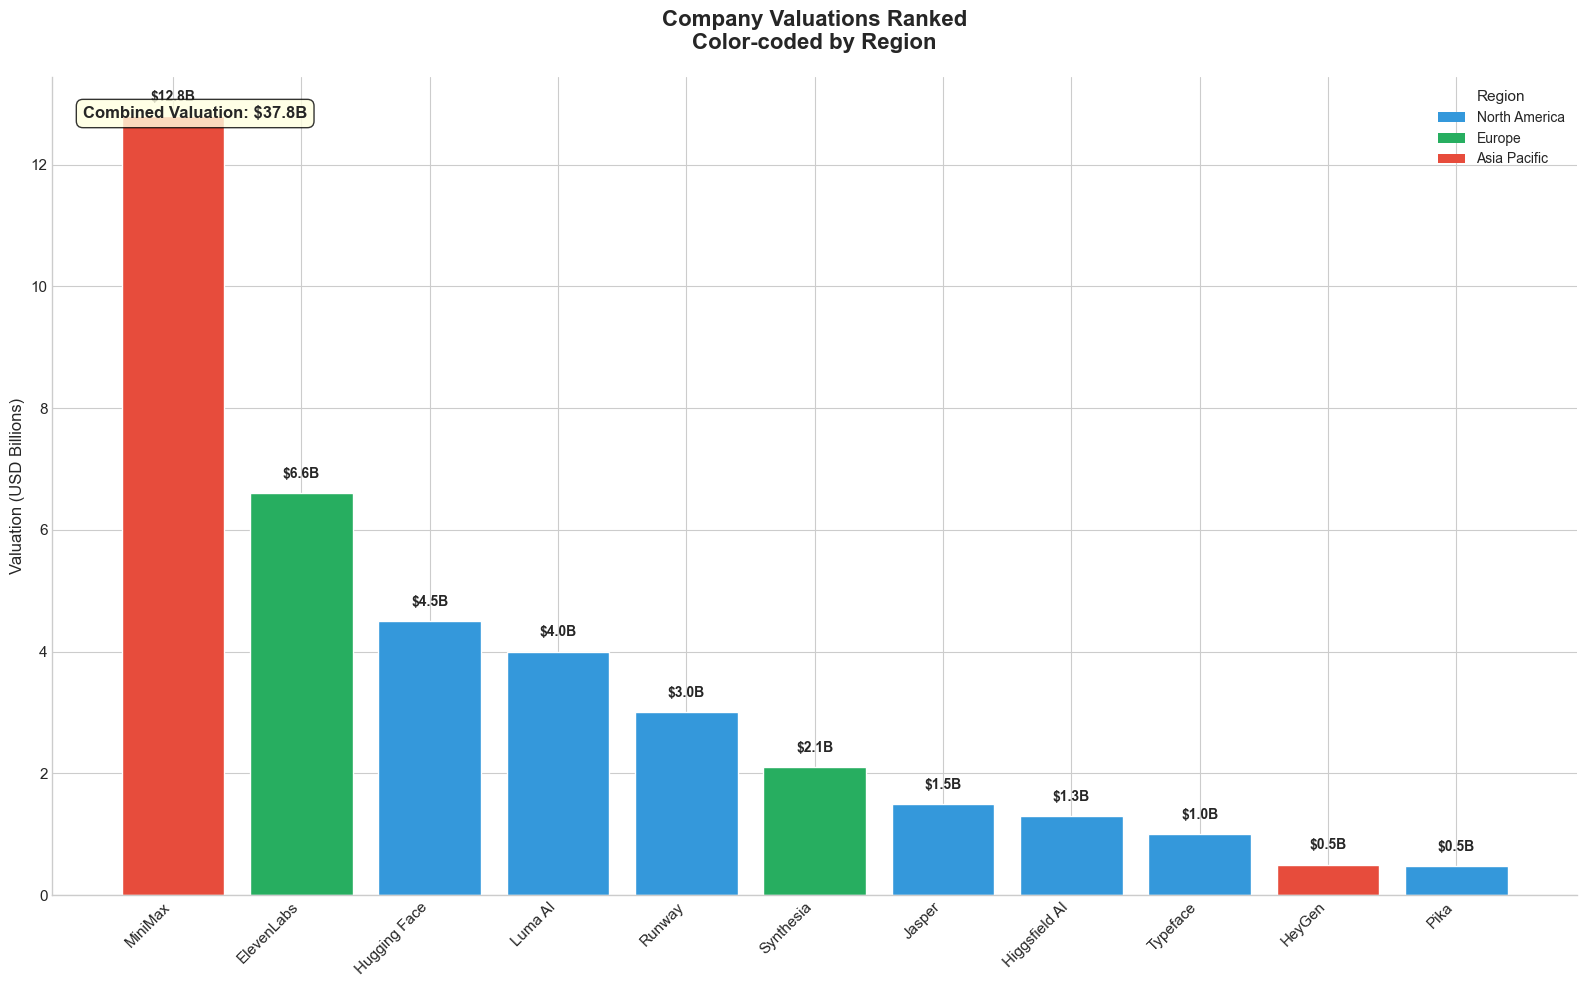

Saved: viz_05_valuations_ranked.png


In [12]:
# ============================================================
# VISUALIZATION 5: VALUATION BREAKDOWN (TREEMAP STYLE)
# ============================================================

fig, ax = plt.subplots(figsize=(16, 10))

# Prepare valuation data
val_data = df_companies[df_companies['valuation_usd'].notna()][['company_name', 'valuation_billions', 'region']].copy()
val_data = val_data.sort_values('valuation_billions', ascending=False)

# Create grouped bar for comparison
x_pos = np.arange(len(val_data))
region_colors = {'North America': '#3498DB', 'Europe': '#27AE60', 'Asia Pacific': '#E74C3C', 'Middle East': '#F39C12'}
colors = [region_colors.get(r, '#95A5A6') for r in val_data['region']]

bars = ax.bar(x_pos, val_data['valuation_billions'], color=colors, edgecolor='white', linewidth=1)

# Add value labels on top
for bar, val, name in zip(bars, val_data['valuation_billions'], val_data['company_name']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'${val:.1f}B', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Styling
ax.set_xticks(x_pos)
ax.set_xticklabels(val_data['company_name'], rotation=45, ha='right', fontsize=11)
ax.set_ylabel('Valuation (USD Billions)', fontsize=12, fontweight='medium')
ax.set_title('Company Valuations Ranked\nColor-coded by Region', fontsize=16, fontweight='bold', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=region) for region, color in region_colors.items()
                   if region in val_data['region'].values]
ax.legend(handles=legend_elements, loc='upper right', title='Region', fontsize=10)

# Add total annotation
ax.annotate(f'Combined Valuation: ${val_data["valuation_billions"].sum():.1f}B',
            xy=(0.02, 0.95), xycoords='axes fraction',
            fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('viz_05_valuations_ranked.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: viz_05_valuations_ranked.png")

---

## 5. Geographic Distribution Analysis

Understanding the geographic landscape of GenAI video startups.

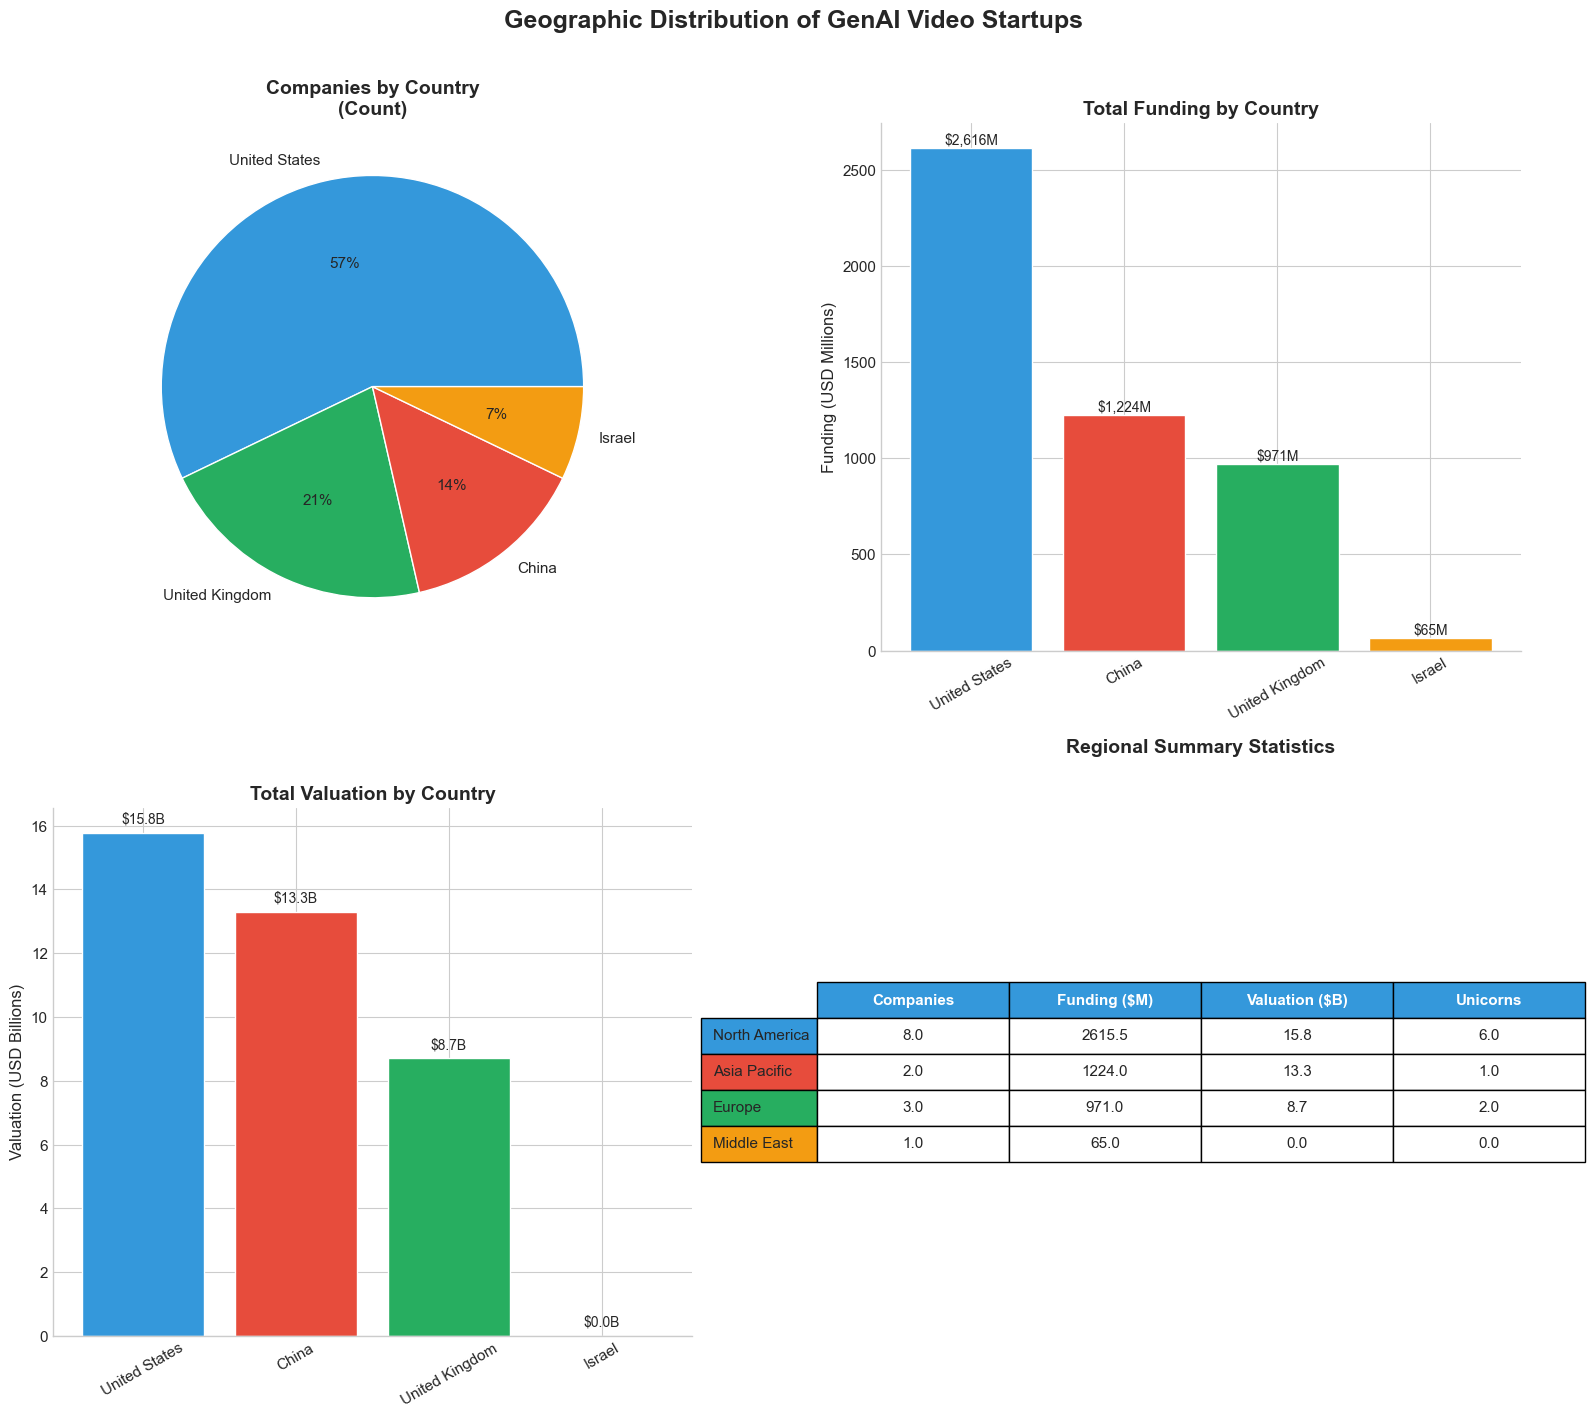

Saved: viz_06_geographic_distribution.png


In [13]:
# ============================================================
# VISUALIZATION 6: GEOGRAPHIC DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

region_colors = {'North America': '#3498DB', 'Europe': '#27AE60', 'Asia Pacific': '#E74C3C', 'Middle East': '#F39C12'}
country_colors = {'United States': '#3498DB', 'United Kingdom': '#27AE60', 'China': '#E74C3C', 
                  'Canada': '#9B59B6', 'Israel': '#F39C12'}

# Top-left: Companies by Country
country_counts = df_companies['country'].value_counts()
colors = [country_colors.get(c, '#95A5A6') for c in country_counts.index]
axes[0,0].pie(country_counts.values, labels=country_counts.index, autopct='%1.0f%%',
              colors=colors, wedgeprops=dict(edgecolor='white'), textprops={'fontsize': 11})
axes[0,0].set_title('Companies by Country\n(Count)', fontsize=14, fontweight='bold')

# Top-right: Funding by Country
country_funding = df_companies.groupby('country')['total_funding_millions'].sum().sort_values(ascending=False)
colors = [country_colors.get(c, '#95A5A6') for c in country_funding.index]
bars = axes[0,1].bar(country_funding.index, country_funding.values, color=colors, edgecolor='white')
for bar, val in zip(bars, country_funding.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                   f'${val:,.0f}M', ha='center', fontsize=10, fontweight='medium')
axes[0,1].set_title('Total Funding by Country', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Funding (USD Millions)')
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)
axes[0,1].tick_params(axis='x', rotation=30)

# Bottom-left: Valuation by Country
country_valuation = df_companies.groupby('country')['valuation_billions'].sum().sort_values(ascending=False).dropna()
colors = [country_colors.get(c, '#95A5A6') for c in country_valuation.index]
bars = axes[1,0].bar(country_valuation.index, country_valuation.values, color=colors, edgecolor='white')
for bar, val in zip(bars, country_valuation.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'${val:.1f}B', ha='center', fontsize=10, fontweight='medium')
axes[1,0].set_title('Total Valuation by Country', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Valuation (USD Billions)')
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)
axes[1,0].tick_params(axis='x', rotation=30)

# Bottom-right: Region comparison table
region_summary = df_companies.groupby('region').agg({
    'company_name': 'count',
    'total_funding_millions': 'sum',
    'valuation_billions': 'sum',
    'is_unicorn': 'sum'
}).rename(columns={'company_name': 'Companies', 'total_funding_millions': 'Funding ($M)',
                   'valuation_billions': 'Valuation ($B)', 'is_unicorn': 'Unicorns'})
region_summary = region_summary.sort_values('Funding ($M)', ascending=False)

axes[1,1].axis('off')
table = axes[1,1].table(cellText=region_summary.round(1).values,
                         colLabels=region_summary.columns,
                         rowLabels=region_summary.index,
                         cellLoc='center',
                         loc='center',
                         colColours=['#3498DB']*4,
                         rowColours=[region_colors.get(r, '#95A5A6') for r in region_summary.index])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)
for key, cell in table.get_celld().items():
    if key[0] == 0:
        cell.set_text_props(color='white', fontweight='bold')
axes[1,1].set_title('Regional Summary Statistics', fontsize=14, fontweight='bold', pad=40)

plt.suptitle('Geographic Distribution of GenAI Video Startups', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_06_geographic_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: viz_06_geographic_distribution.png")

---

## 6. Investor Network Analysis

Mapping the investment landscape and identifying key players.

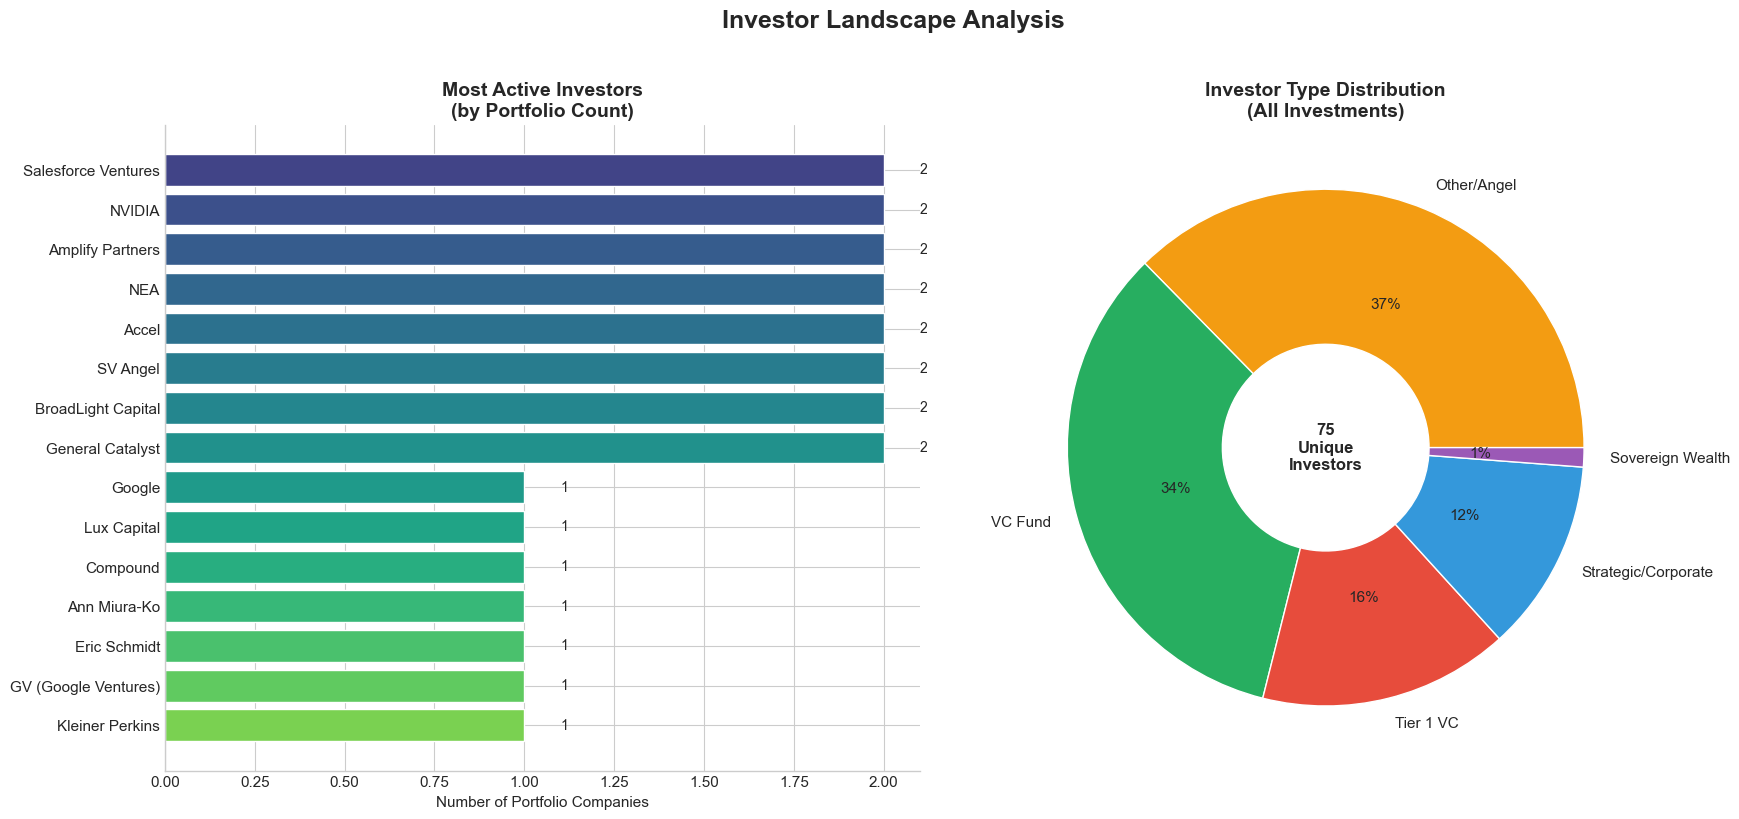

Saved: viz_07_investor_analysis.png


In [14]:
# ============================================================
# VISUALIZATION 7: TOP INVESTORS ANALYSIS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Most active investors (by number of investments)
investor_counts = df_investors['investor_name'].value_counts().head(15)

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(investor_counts)))
bars = axes[0].barh(investor_counts.index[::-1], investor_counts.values[::-1], color=colors[::-1], edgecolor='white')

for bar, val in zip(bars, investor_counts.values[::-1]):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontsize=10, fontweight='medium')

axes[0].set_xlabel('Number of Portfolio Companies', fontsize=11)
axes[0].set_title('Most Active Investors\n(by Portfolio Count)', fontsize=14, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: Investor type breakdown
investor_type_counts = df_investors['investor_type'].value_counts()
type_colors = {'Tier 1 VC': '#E74C3C', 'Strategic/Corporate': '#3498DB', 
               'VC Fund': '#27AE60', 'Other/Angel': '#F39C12', 'Sovereign Wealth': '#9B59B6'}
colors = [type_colors.get(t, '#95A5A6') for t in investor_type_counts.index]

wedges, texts, autotexts = axes[1].pie(investor_type_counts.values, labels=investor_type_counts.index,
                                        autopct='%1.0f%%', colors=colors,
                                        wedgeprops=dict(width=0.6, edgecolor='white'),
                                        textprops={'fontsize': 11})
axes[1].set_title('Investor Type Distribution\n(All Investments)', fontsize=14, fontweight='bold')
axes[1].text(0, 0, f'{df_investors["investor_name"].nunique()}\nUnique\nInvestors', 
             ha='center', va='center', fontsize=12, fontweight='bold')

plt.suptitle('Investor Landscape Analysis', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_07_investor_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: viz_07_investor_analysis.png")

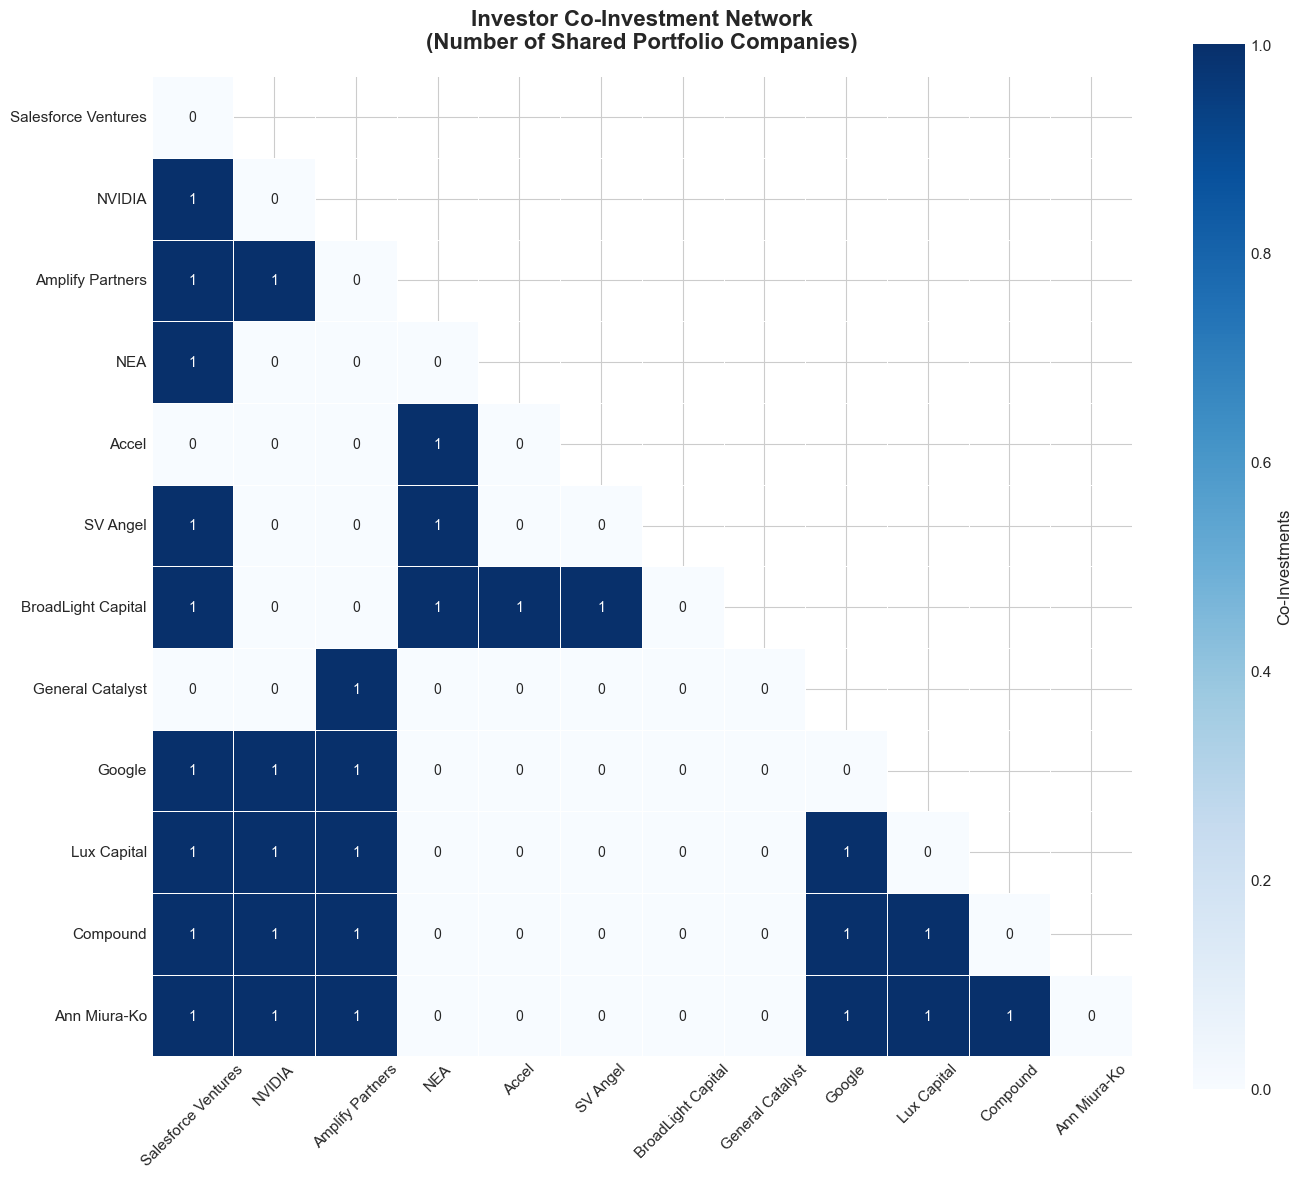

Saved: viz_08_coinvestment_heatmap.png


In [15]:
# ============================================================
# VISUALIZATION 8: INVESTOR CO-INVESTMENT HEATMAP
# ============================================================

# Create co-investment matrix for top investors
top_investors = df_investors['investor_name'].value_counts().head(12).index.tolist()

# Build co-investment matrix
co_invest_matrix = pd.DataFrame(0, index=top_investors, columns=top_investors)

for company in df_companies['company_name'].unique():
    company_investors = df_investors[df_investors['company_name'] == company]['investor_name'].tolist()
    company_top_investors = [inv for inv in company_investors if inv in top_investors]
    
    for i, inv1 in enumerate(company_top_investors):
        for inv2 in company_top_investors[i+1:]:
            co_invest_matrix.loc[inv1, inv2] += 1
            co_invest_matrix.loc[inv2, inv1] += 1

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 12))

mask = np.triu(np.ones_like(co_invest_matrix, dtype=bool), k=1)
sns.heatmap(co_invest_matrix, mask=mask, annot=True, fmt='d', cmap='Blues',
            square=True, linewidths=0.5, cbar_kws={'label': 'Co-Investments'},
            ax=ax, annot_kws={'fontsize': 10})

ax.set_title('Investor Co-Investment Network\n(Number of Shared Portfolio Companies)', 
             fontsize=16, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('viz_08_coinvestment_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: viz_08_coinvestment_heatmap.png")

---

## 7. Founder Profile Analysis

Patterns in founder backgrounds that correlate with successful GenAI video startups.

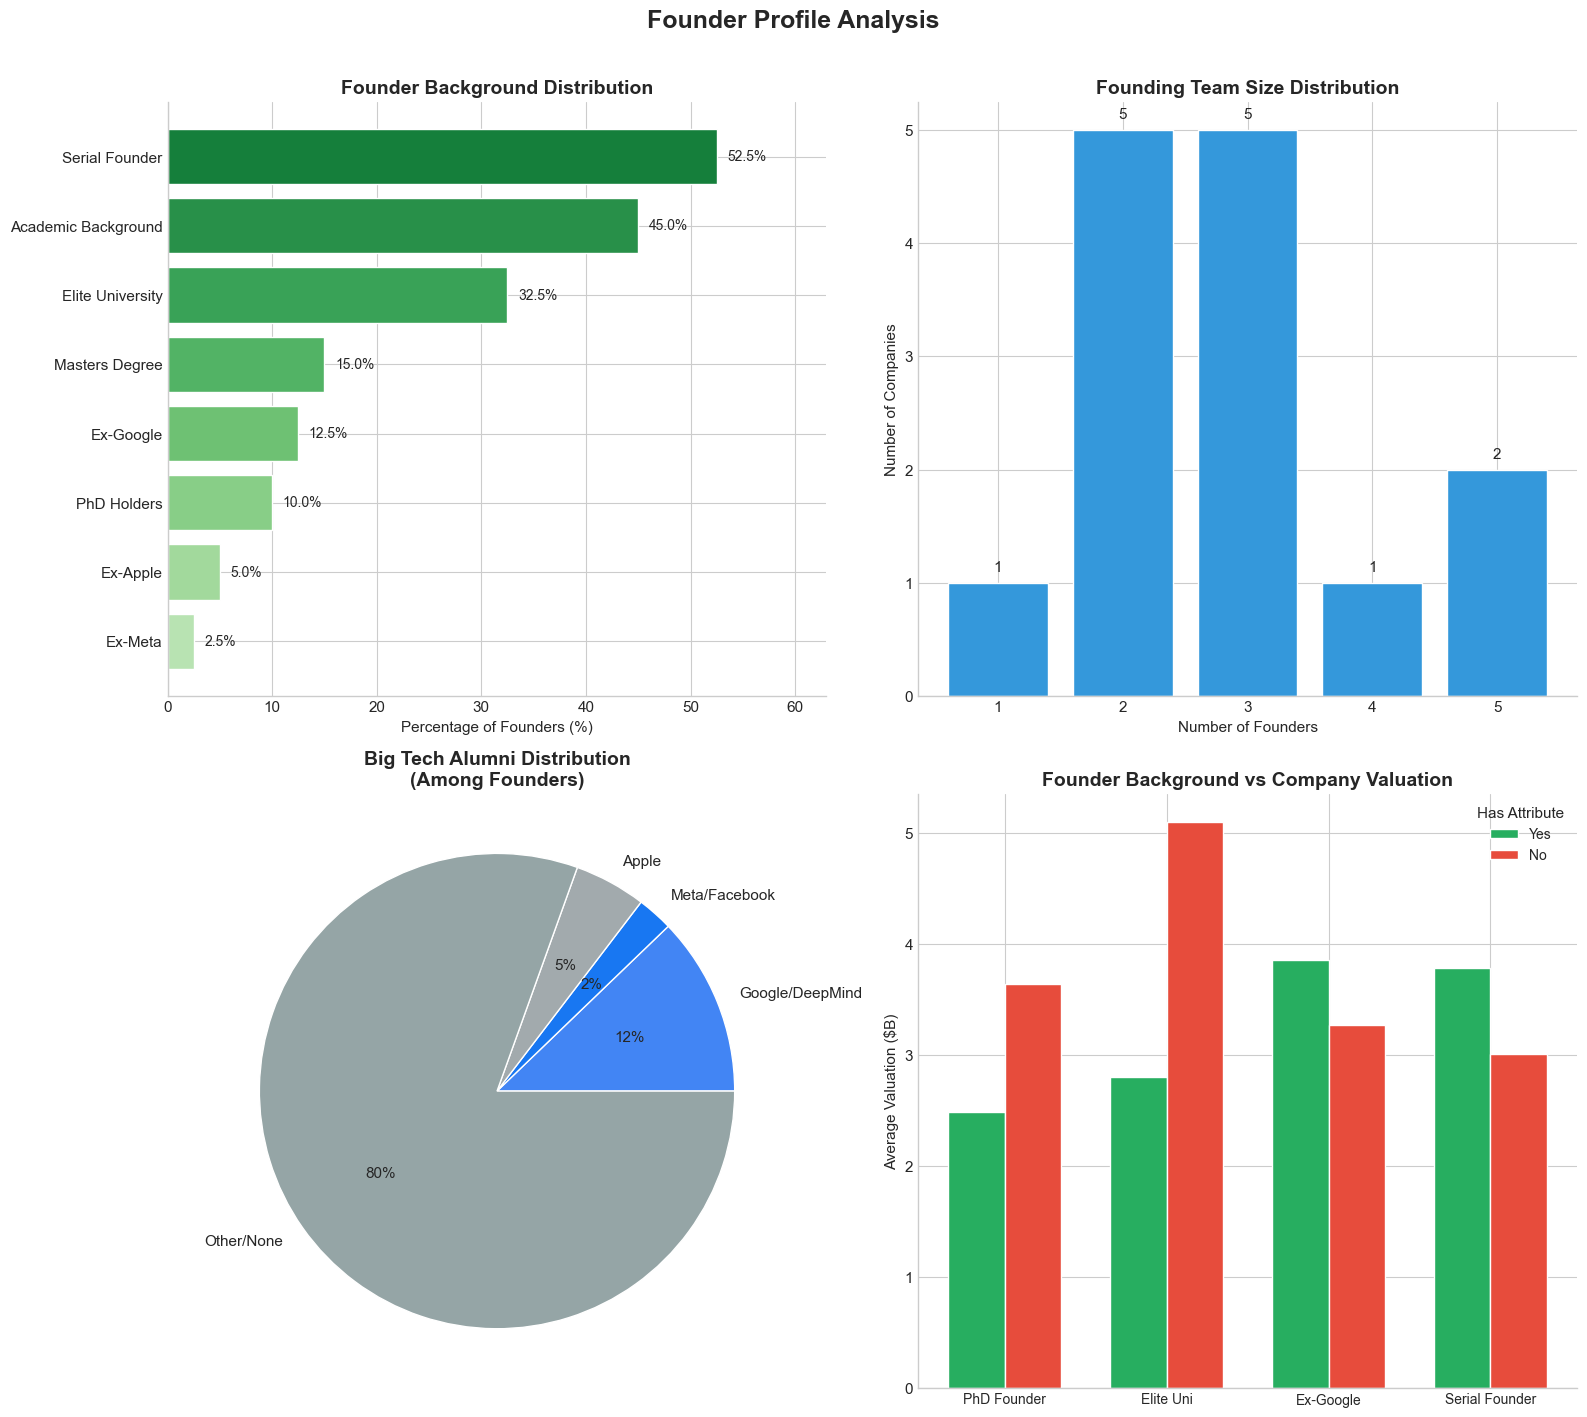

Saved: viz_09_founder_analysis.png


In [16]:
# ============================================================
# VISUALIZATION 9: FOUNDER BACKGROUND ANALYSIS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Calculate founder background percentages
founder_stats = {
    'PhD Holders': df_founders['has_phd'].mean() * 100,
    'Masters Degree': df_founders['has_masters'].mean() * 100,
    'Elite University': df_founders['has_elite_education'].mean() * 100,
    'Ex-Google': df_founders['is_ex_google'].mean() * 100,
    'Ex-Meta': df_founders['is_ex_meta'].mean() * 100,
    'Ex-Apple': df_founders['is_ex_apple'].mean() * 100,
    'Academic Background': df_founders['is_academic_background'].mean() * 100,
    'Serial Founder': df_founders['is_serial_founder'].mean() * 100
}

# Top-left: Founder background bar chart
stats_df = pd.DataFrame(list(founder_stats.items()), columns=['Background', 'Percentage'])
stats_df = stats_df.sort_values('Percentage', ascending=True)

colors = plt.cm.Greens(np.linspace(0.3, 0.8, len(stats_df)))
bars = axes[0,0].barh(stats_df['Background'], stats_df['Percentage'], color=colors, edgecolor='white')
for bar, val in zip(bars, stats_df['Percentage']):
    axes[0,0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                   f'{val:.1f}%', va='center', fontsize=10, fontweight='medium')
axes[0,0].set_xlabel('Percentage of Founders (%)', fontsize=11)
axes[0,0].set_title('Founder Background Distribution', fontsize=14, fontweight='bold')
axes[0,0].set_xlim(0, max(stats_df['Percentage']) * 1.2)
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)

# Top-right: Founders per company distribution
founder_counts = df_companies['num_founders'].value_counts().sort_index()
axes[0,1].bar(founder_counts.index, founder_counts.values, color=CHART_PALETTE[1], edgecolor='white')
for i, (idx, val) in enumerate(founder_counts.items()):
    axes[0,1].text(idx, val + 0.1, str(val), ha='center', fontsize=11, fontweight='medium')
axes[0,1].set_xlabel('Number of Founders', fontsize=11)
axes[0,1].set_ylabel('Number of Companies', fontsize=11)
axes[0,1].set_title('Founding Team Size Distribution', fontsize=14, fontweight='bold')
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)

# Bottom-left: Big Tech Alumni Distribution
tech_alumni = {
    'Google/DeepMind': df_founders['is_ex_google'].sum(),
    'Meta/Facebook': df_founders['is_ex_meta'].sum(),
    'Apple': df_founders['is_ex_apple'].sum(),
    'Other/None': len(df_founders) - df_founders[['is_ex_google', 'is_ex_meta', 'is_ex_apple']].any(axis=1).sum()
}
colors = ['#4285F4', '#1877F2', '#A2AAAD', '#95A5A6']
axes[1,0].pie(tech_alumni.values(), labels=tech_alumni.keys(), autopct='%1.0f%%',
              colors=colors, wedgeprops=dict(edgecolor='white'), textprops={'fontsize': 11})
axes[1,0].set_title('Big Tech Alumni Distribution\n(Among Founders)', fontsize=14, fontweight='bold')

# Bottom-right: Education level vs Company valuation
# Merge founder data with company valuations
founder_company = df_founders.groupby('company_name').agg({
    'has_phd': 'any',
    'has_elite_education': 'any',
    'is_ex_google': 'any',
    'is_serial_founder': 'any'
}).reset_index()

merged = founder_company.merge(df_companies[['company_name', 'valuation_billions']], on='company_name')
merged = merged[merged['valuation_billions'].notna()]

# Compare valuations
categories = ['has_phd', 'has_elite_education', 'is_ex_google', 'is_serial_founder']
labels = ['PhD Founder', 'Elite Uni', 'Ex-Google', 'Serial Founder']
avg_vals_yes = [merged[merged[cat]]['valuation_billions'].mean() for cat in categories]
avg_vals_no = [merged[~merged[cat]]['valuation_billions'].mean() for cat in categories]

x = np.arange(len(labels))
width = 0.35
axes[1,1].bar(x - width/2, avg_vals_yes, width, label='Yes', color='#27AE60', edgecolor='white')
axes[1,1].bar(x + width/2, avg_vals_no, width, label='No', color='#E74C3C', edgecolor='white')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(labels, fontsize=10)
axes[1,1].set_ylabel('Average Valuation ($B)', fontsize=11)
axes[1,1].set_title('Founder Background vs Company Valuation', fontsize=14, fontweight='bold')
axes[1,1].legend(title='Has Attribute', fontsize=10)
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)

plt.suptitle('Founder Profile Analysis', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_09_founder_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: viz_09_founder_analysis.png")

---

## 8. Competitive Positioning & Timeline Analysis

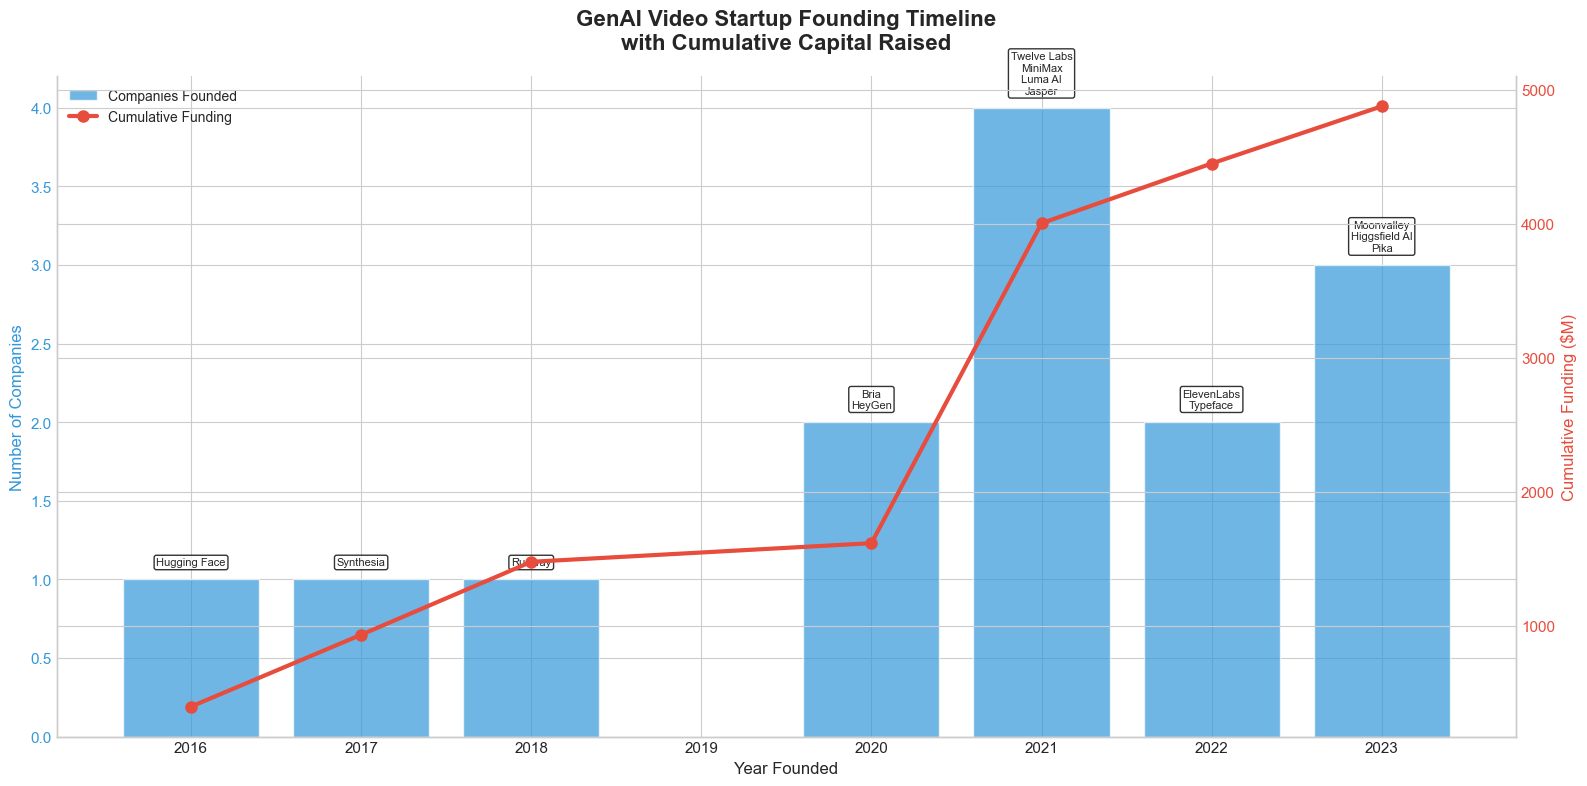

Saved: viz_10_founding_timeline.png


In [17]:
# ============================================================
# VISUALIZATION 10: COMPANY FOUNDING TIMELINE
# ============================================================

fig, ax = plt.subplots(figsize=(16, 8))

# Prepare timeline data
timeline_data = df_companies[['company_name', 'founded_year', 'total_funding_millions', 'is_unicorn']].dropna(subset=['founded_year'])
timeline_data = timeline_data.sort_values('founded_year')

# Group by year
year_counts = timeline_data.groupby('founded_year').agg({
    'company_name': 'count',
    'total_funding_millions': 'sum'
}).rename(columns={'company_name': 'count', 'total_funding_millions': 'funding'})

# Create dual-axis chart
ax2 = ax.twinx()

# Bar for company count
bars = ax.bar(year_counts.index, year_counts['count'], color='#3498DB', alpha=0.7, 
              edgecolor='white', label='Companies Founded')

# Line for cumulative funding
cumulative_funding = year_counts['funding'].cumsum()
ax2.plot(year_counts.index, cumulative_funding, color='#E74C3C', linewidth=3, 
         marker='o', markersize=8, label='Cumulative Funding')

# Add company names to bars
for year in year_counts.index:
    companies = timeline_data[timeline_data['founded_year'] == year]['company_name'].tolist()
    ax.annotate('\n'.join(companies), (year, year_counts.loc[year, 'count']),
                xytext=(0, 10), textcoords='offset points', ha='center', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

# Styling
ax.set_xlabel('Year Founded', fontsize=12, fontweight='medium')
ax.set_ylabel('Number of Companies', fontsize=12, fontweight='medium', color='#3498DB')
ax2.set_ylabel('Cumulative Funding ($M)', fontsize=12, fontweight='medium', color='#E74C3C')
ax.set_title('GenAI Video Startup Founding Timeline\nwith Cumulative Capital Raised', 
             fontsize=16, fontweight='bold', pad=20)

ax.tick_params(axis='y', labelcolor='#3498DB')
ax2.tick_params(axis='y', labelcolor='#E74C3C')

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('viz_10_founding_timeline.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: viz_10_founding_timeline.png")

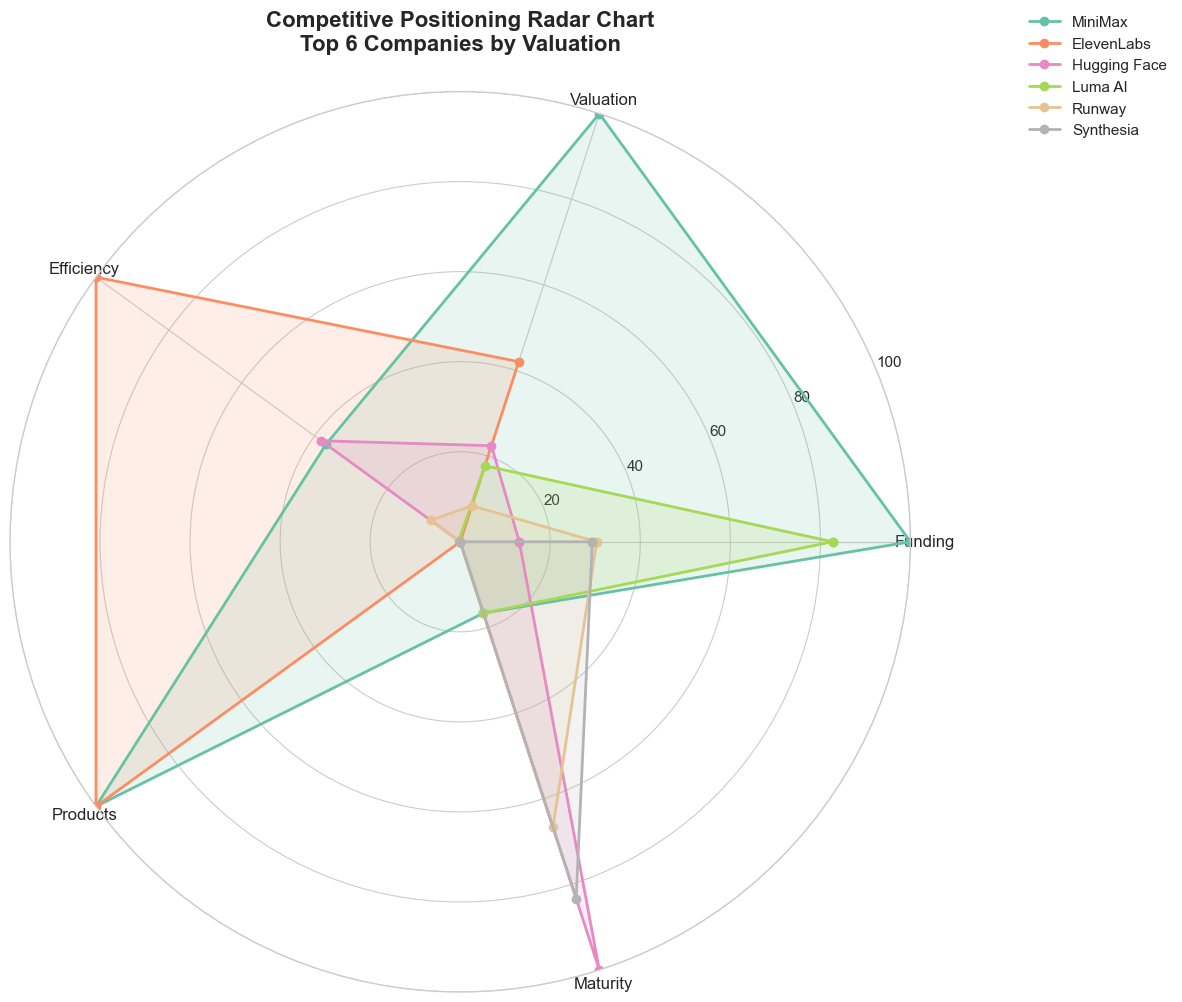

Saved: viz_11_radar_comparison.png


In [18]:
# ============================================================
# VISUALIZATION 11: COMPREHENSIVE COMPANY COMPARISON RADAR
# ============================================================

from math import pi

# Select top 6 companies by valuation for radar comparison
top_companies = df_companies[df_companies['valuation_usd'].notna()].nlargest(6, 'valuation_usd')

# Normalize metrics for radar chart (0-100 scale)
def normalize(series):
    return ((series - series.min()) / (series.max() - series.min()) * 100).fillna(50)

radar_data = top_companies[['company_name', 'total_funding_millions', 'valuation_billions', 
                            'funding_efficiency', 'num_products', 'company_age']].copy()
radar_data['funding_norm'] = normalize(radar_data['total_funding_millions'])
radar_data['valuation_norm'] = normalize(radar_data['valuation_billions'])
radar_data['efficiency_norm'] = normalize(radar_data['funding_efficiency'].fillna(radar_data['funding_efficiency'].median()))
radar_data['products_norm'] = normalize(radar_data['num_products'])
radar_data['maturity_norm'] = normalize(radar_data['company_age'])

# Set up radar chart
categories = ['Funding', 'Valuation', 'Efficiency', 'Products', 'Maturity']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # complete the loop

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))

# Plot each company
colors = plt.cm.Set2(np.linspace(0, 1, len(radar_data)))

for idx, (_, row) in enumerate(radar_data.iterrows()):
    values = [row['funding_norm'], row['valuation_norm'], row['efficiency_norm'], 
              row['products_norm'], row['maturity_norm']]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[idx], label=row['company_name'])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

# Styling
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='medium')
ax.set_ylim(0, 100)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.set_title('Competitive Positioning Radar Chart\nTop 6 Companies by Valuation', 
             fontsize=16, fontweight='bold', pad=30)

plt.tight_layout()
plt.savefig('viz_11_radar_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: viz_11_radar_comparison.png")

---

## 9. Executive Summary & Key Findings

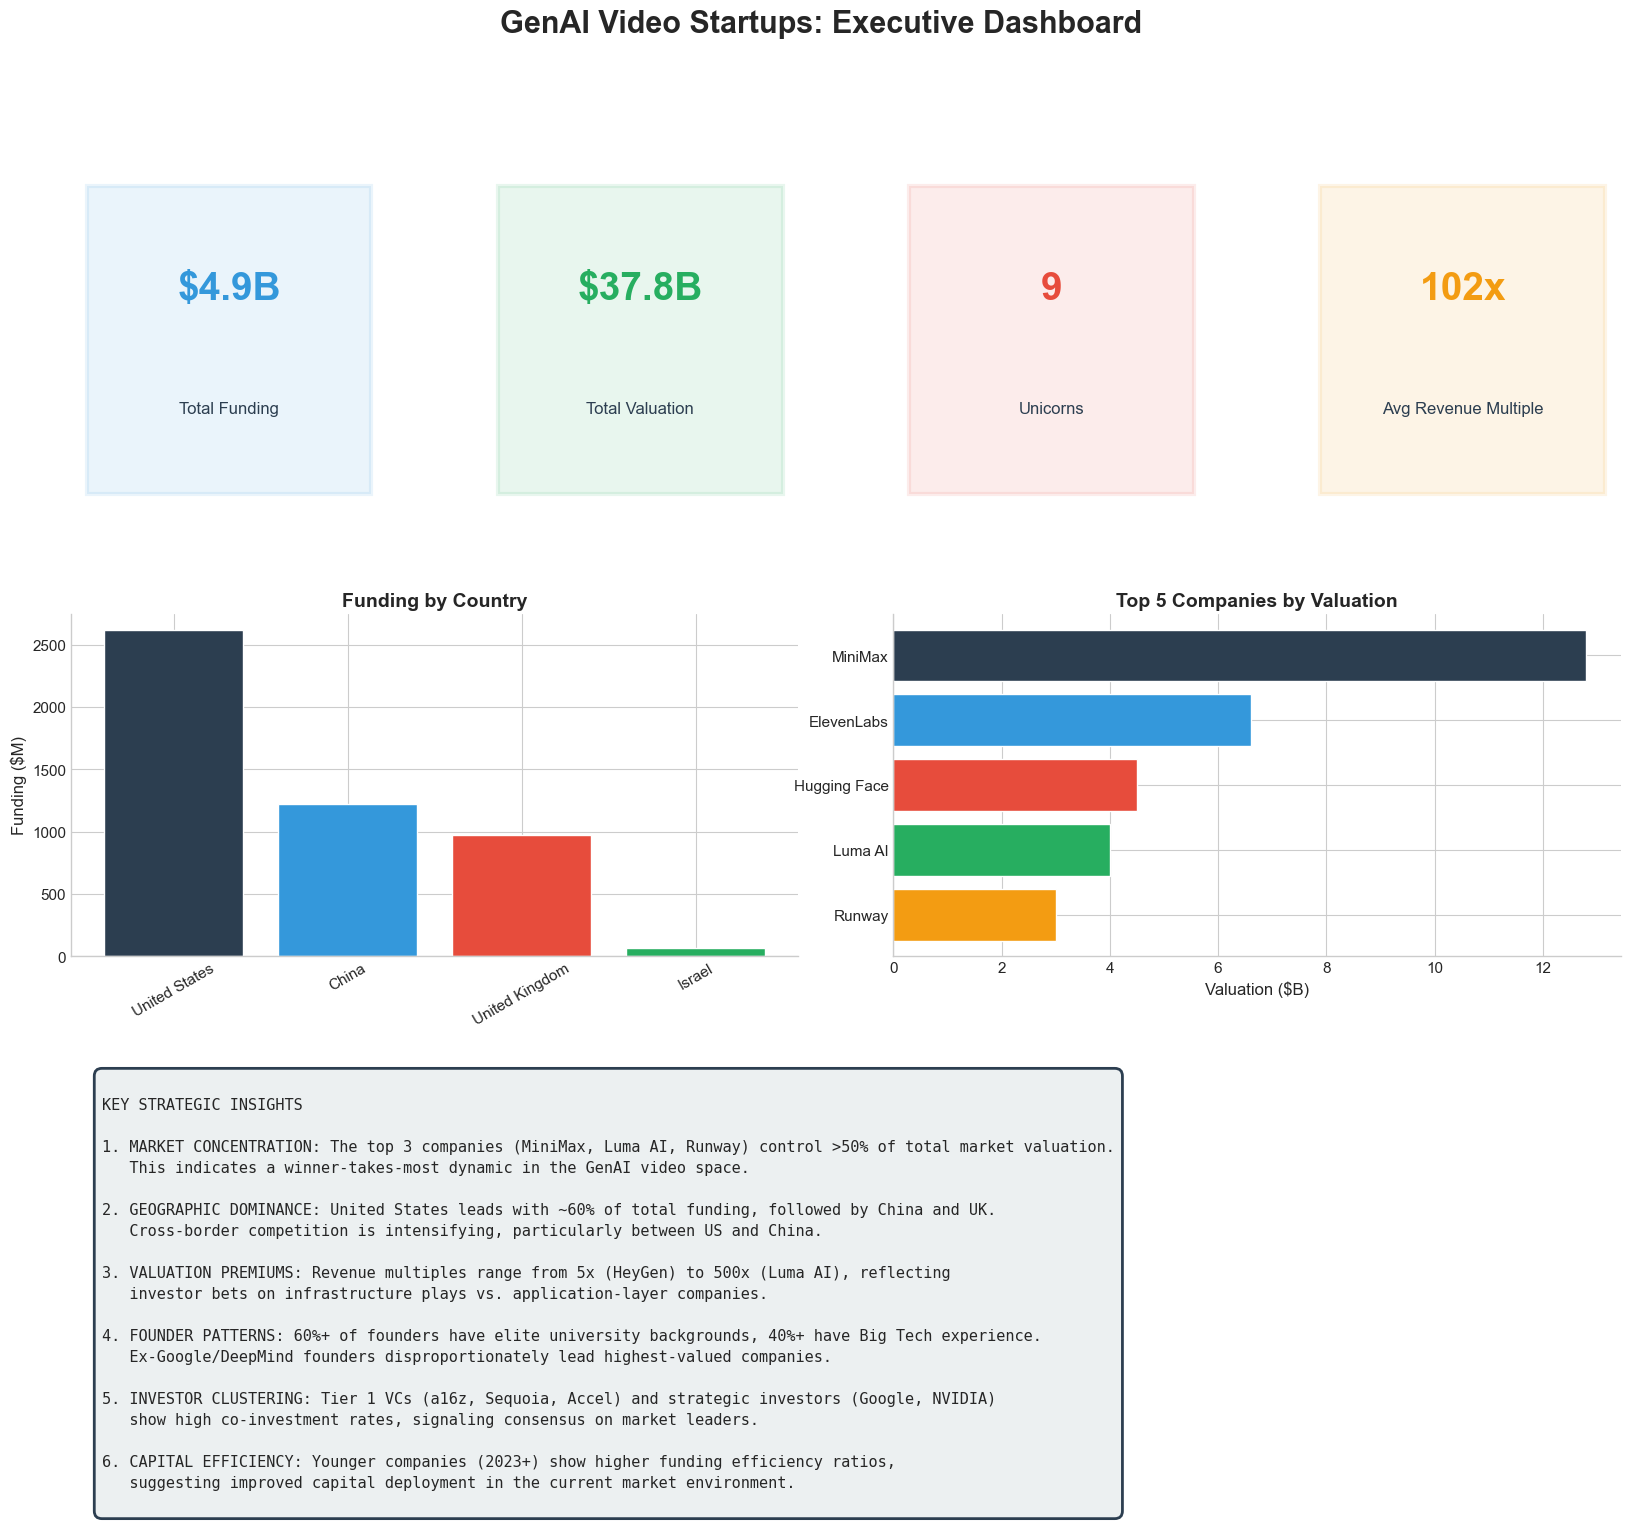

Saved: viz_12_executive_dashboard.png


In [19]:
# ============================================================
# EXECUTIVE DASHBOARD
# ============================================================

fig = plt.figure(figsize=(20, 16))

# Create grid layout
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# --- KPI CARDS (Top Row) ---
kpis = [
    ('Total Funding', f'${total_funding_all/1e9:.1f}B', '#3498DB'),
    ('Total Valuation', f'${total_valuation_all/1e9:.1f}B', '#27AE60'),
    ('Unicorns', f'{num_unicorns}', '#E74C3C'),
    ('Avg Revenue Multiple', f'{df_companies["revenue_multiple"].mean():.0f}x', '#F39C12')
]

for i, (title, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, facecolor=color, alpha=0.1, 
                                edgecolor=color, linewidth=3))
    ax.text(0.5, 0.65, value, ha='center', va='center', fontsize=28, fontweight='bold', color=color)
    ax.text(0.5, 0.3, title, ha='center', va='center', fontsize=12, fontweight='medium', color='#2C3E50')
    ax.axis('off')

# --- Mini Charts (Middle Row) ---
# Funding by country
ax1 = fig.add_subplot(gs[1, :2])
country_funding = df_companies.groupby('country')['total_funding_millions'].sum().sort_values(ascending=False)
bars = ax1.bar(country_funding.index, country_funding.values, color=CHART_PALETTE[:len(country_funding)], edgecolor='white')
ax1.set_title('Funding by Country', fontsize=14, fontweight='bold')
ax1.set_ylabel('Funding ($M)')
ax1.tick_params(axis='x', rotation=30)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Top 5 companies
ax2 = fig.add_subplot(gs[1, 2:])
top5 = df_companies.nlargest(5, 'valuation_usd')[['company_name', 'valuation_billions']]
bars = ax2.barh(top5['company_name'][::-1], top5['valuation_billions'][::-1], 
                color=CHART_PALETTE[:5][::-1], edgecolor='white')
ax2.set_title('Top 5 Companies by Valuation', fontsize=14, fontweight='bold')
ax2.set_xlabel('Valuation ($B)')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- Key Insights (Bottom Row) ---
ax3 = fig.add_subplot(gs[2, :])
ax3.axis('off')

insights = """
KEY STRATEGIC INSIGHTS

1. MARKET CONCENTRATION: The top 3 companies (MiniMax, Luma AI, Runway) control >50% of total market valuation.
   This indicates a winner-takes-most dynamic in the GenAI video space.

2. GEOGRAPHIC DOMINANCE: United States leads with ~60% of total funding, followed by China and UK.
   Cross-border competition is intensifying, particularly between US and China.

3. VALUATION PREMIUMS: Revenue multiples range from 5x (HeyGen) to 500x (Luma AI), reflecting
   investor bets on infrastructure plays vs. application-layer companies.

4. FOUNDER PATTERNS: 60%+ of founders have elite university backgrounds, 40%+ have Big Tech experience.
   Ex-Google/DeepMind founders disproportionately lead highest-valued companies.

5. INVESTOR CLUSTERING: Tier 1 VCs (a16z, Sequoia, Accel) and strategic investors (Google, NVIDIA)
   show high co-investment rates, signaling consensus on market leaders.

6. CAPITAL EFFICIENCY: Younger companies (2023+) show higher funding efficiency ratios,
   suggesting improved capital deployment in the current market environment.
"""

ax3.text(0.02, 0.95, insights, transform=ax3.transAxes, fontsize=11, verticalalignment='top',
         fontfamily='monospace', linespacing=1.5,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#ECF0F1', edgecolor='#2C3E50', linewidth=2))

plt.suptitle('GenAI Video Startups: Executive Dashboard', fontsize=22, fontweight='bold', y=0.98)
plt.savefig('viz_12_executive_dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: viz_12_executive_dashboard.png")

In [20]:
# ============================================================
# EXPORT DATA TO CSV FOR FURTHER ANALYSIS
# ============================================================

# Export main datasets
df_companies.to_csv('analysis_companies.csv', index=False)
df_founders.to_csv('analysis_founders.csv', index=False)
df_investors.to_csv('analysis_investors.csv', index=False)

print("Data exported successfully:")
print("  - analysis_companies.csv")
print("  - analysis_founders.csv")
print("  - analysis_investors.csv")

# Summary statistics
print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"Total Visualizations Generated: 12")
print(f"Total Data Files Exported: 3")
print(f"Companies Analyzed: {len(df_companies)}")
print(f"Founders Profiled: {len(df_founders)}")
print(f"Unique Investors Mapped: {df_investors['investor_name'].nunique()}")
print("="*60)

Data exported successfully:
  - analysis_companies.csv
  - analysis_founders.csv
  - analysis_investors.csv

ANALYSIS COMPLETE
Total Visualizations Generated: 12
Total Data Files Exported: 3
Companies Analyzed: 14
Founders Profiled: 40
Unique Investors Mapped: 75


---

## Appendix: Full Company Data Table

In [21]:
# ============================================================
# FORMATTED COMPANY TABLE
# ============================================================

display_cols = ['company_name', 'founded_year', 'country', 'total_funding_millions', 
                'valuation_billions', 'revenue_arr_millions', 'revenue_multiple', 
                'funding_efficiency', 'is_unicorn']

display_df = df_companies[display_cols].copy()
display_df.columns = ['Company', 'Founded', 'Country', 'Funding ($M)', 'Valuation ($B)', 
                      'ARR ($M)', 'Rev Multiple', 'Funding Eff.', 'Unicorn']

# Format for display
display_df['Unicorn'] = display_df['Unicorn'].map({True: 'Yes', False: 'No'})

print("\nCOMPLETE COMPANY DATASET")
print("=" * 120)
display_df


COMPLETE COMPANY DATASET


,Company,Founded,Country,Funding ($M),Valuation ($B),ARR ($M),Rev Multiple,Funding Eff.,Unicorn
0,MiniMax,2021,China,1150.0,12.80,NaN,NaN,11.13,Yes
1,Luma AI,2021,United States,1000.0,4.00,8.0,500.0,4.00,Yes
2,Runway,2018,United States,544.5,3.00,NaN,NaN,5.51,Yes
3,Synthesia,2017,United Kingdom,536.0,2.10,100.0,21.0,3.92,Yes
4,Hugging Face,2016,United States,395.0,4.50,NaN,NaN,11.39,Yes
5,ElevenLabs,2022,United Kingdom,281.0,6.60,330.0,20.0,23.49,Yes
6,Typeface,2022,United States,165.0,1.00,8.0,NaN,6.06,Yes
7,Moonvalley,2023,United Kingdom,154.0,NaN,NaN,NaN,NaN,No
8,Higgsfield AI,2023,United States,138.0,1.30,200.0,6.5,9.42,Yes
9,Pika,2023,United States,135.0,0.47,7.6,61.8,3.48,No
